## Survey analyses-focused on secretor status

In [2]:
# Importing packages for:
# Importing and analysis
import pandas as pd 
import numpy as np
import re

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Correlation
from scipy.stats import chi2_contingency, fisher_exact
import math

## Load dataset

In [4]:
# Load dataset- loading most upto date file- clean data attempted to remove wong, mistyped and nonsense answers
Survey =pd.read_excel("Survey_results_359_19122025.xlsx", sheet_name='cleaned_data')

In [5]:
# Create dataframe with only endo patients
Survey_endo_only = Survey[Survey['Have you been diagnosed with endometriosis?'] == 'Yes, confirmed by laparoscopic surgery']

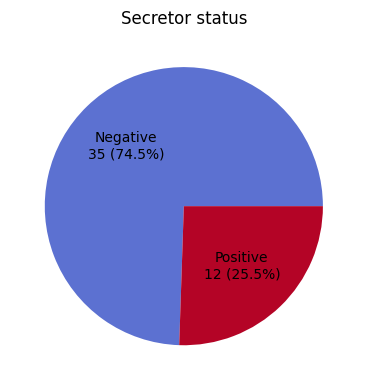

In [6]:
# What is your secretor status

# Counnt responses
counts = Survey_endo_only["What is your secretor status"].value_counts()

# Define colors
color_map = {"Positive": "#b40426", "Negative":"#5c71d1"}
colors = [color_map[label] for label in counts.index]

plt.figure(figsize=(4, 4))

# Initial pie chart with placeholder autopct
wedges, texts, autotexts = plt.pie(
    counts,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',  
)

# Update each slice label with category, count, and percentage
total = counts.sum()
for i, a in enumerate(autotexts):
    label = counts.index[i]
    count = counts.iloc[i]  
    pct = (count / total) * 100
    a.set_text(f"{label}\n{count} ({pct:.1f}%)")

plt.title("Secretor status")
plt.tight_layout()
plt.show()

# General population has 80% positive secretor status

In [7]:
# Select only patients with known secretor status
# Filter rows where 'What is your secretor status' is not null
Survey_endo_only_sec = Survey_endo_only.dropna(subset=['What is your secretor status'])

In [8]:
# Export to excel
Survey_endo_only_sec.to_excel("Survey_endo_only_sec.xlsx", index=False)

# Comparison secretor negative vs positive Endo patients

## Custom reusable function

In [11]:
# Setup: imports + reusable plotting/stats function 

# Try SciPy Fisher; fall back if not available
try:
    from scipy.stats import fisher_exact as fisher_exact_scipy
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Colors + groups (Negative blue, Positive red)
DEFAULT_SECRETOR_COL = "What is your secretor status"
DEFAULT_SECRETOR_GROUPS = ("Negative", "Positive")
DEFAULT_COLORS = {"Negative": "#5c71d1", "Positive": "#b40426"}  # blue/red

# Stats helpers

def is_valid_2x2_rows(a, b, c, d):
    """Valid for Fisher only when both row totals > 0 and both column totals > 0."""
    return not ((a + b == 0) or (c + d == 0) or (a + c == 0) or (b + d == 0))

def is_finite_number(x):
    """True only if x is a real finite float/int."""
    return isinstance(x, (int, float)) and np.isfinite(x)

def benjamini_hochberg(pvals):
    p = np.array([1.0 if (v is None or (isinstance(v, float) and np.isnan(v))) else float(v) for v in pvals], dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty(n)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        qval = ranked[i] * n / rank
        prev = min(prev, qval)
        q[i] = prev
    q_final = np.empty(n)
    q_final[order] = q
    return q_final

def safe_fisher_exact_scipy(table_or_a, b=None, c=None, d=None, alternative="two-sided"):
    """
    Flexible + safe wrapper around scipy.stats.fisher_exact.

    Usage:
      safe_fisher_exact_scipy([[a, b], [c, d]], alternative="two-sided")
      safe_fisher_exact_scipy(a, b, c, d, alternative="two-sided")

    Returns:
      (or_estimate, p_value) or (None, None) if invalid or an error occurs.

    Behavior:
      - Accepts both a nested 2x2 container or 4 scalar arguments.
      - Validates the 2x2 table and returns (None, None) for invalid tables:
          * any row total = 0
          * any column total = 0
      - Uses SciPy if available; otherwise returns (None, None).
      - Normalizes infinite OR to None for downstream stability.
    """
    # Unpack arguments to scalars a,b,c,d
    if b is None and c is None and d is None:
        # Called with 2x2 table
        tbl = table_or_a
        try:
            a = int(tbl[0][0]); b = int(tbl[0][1])
            c = int(tbl[1][0]); d = int(tbl[1][1])
        except Exception:
            return None, None
    else:
        # Called with four scalars
        try:
            a = int(table_or_a); b = int(b); c = int(c); d = int(d)
        except Exception:
            return None, None

    # Basic validity checks for Fisher’s test:
    # - Row totals > 0 and column totals > 0
    if (a + b == 0) or (c + d == 0) or (a + c == 0) or (b + d == 0):
        return None, None

    # Try SciPy
    try:
        from scipy.stats import fisher_exact
    except Exception:
        # SciPy not available
        return None, None

    # Run Fisher’s exact test
    try:
        or_est, p_val = fisher_exact([[a, b], [c, d]], alternative=alternative)
        # Stabilize: normalize inf/NaN OR to None
        if not (isinstance(or_est, (int, float)) and np.isfinite(or_est)):
            or_est = None
        return or_est, p_val
    except Exception:
        return None, None


def fisher_exact_twosided(a, b, c, d):
    from math import comb
    r1 = a + b; r2 = c + d; c1 = a + c; c2 = b + d; n = r1 + r2
    def hypergeom_prob(aa):
        return (comb(c1, aa) * comb(c2, r1 - aa)) / comb(n, r1)
    a_min = max(0, r1 + c1 - n)
    a_max = min(r1, c1)
    p_obs = hypergeom_prob(a)
    p_two = 0.0
    for aa in range(a_min, a_max + 1):
        p = hypergeom_prob(aa)
        if p <= p_obs + 1e-12:
            p_two += p
    aa, bb, cc, dd = a, b, c, d
    if aa == 0 or bb == 0 or cc == 0 or dd == 0:
        aa += 0.5; bb += 0.5; cc += 0.5; dd += 0.5
    or_est = (aa * dd) / (bb * cc)
    return or_est, p_two

def odds_ratio_ci_95(a, b, c, d):
    aa, bb, cc, dd = a, b, c, d
    if aa == 0 or bb == 0 or cc == 0 or dd == 0:
        aa += 0.5; bb += 0.5; cc += 0.5; dd += 0.5
    or_hat = (aa * dd) / (bb * cc)
    se_log_or = np.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
    z = 1.959963984540054
    lo = np.exp(np.log(or_hat) - z * se_log_or)
    hi = np.exp(np.log(or_hat) + z * se_log_or)
    return or_hat, lo, hi

def cohens_h(p1, p2):
    p1 = min(max(p1, 0.0), 1.0); p2 = min(max(p2, 0.0), 1.0)
    h = 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))
    ah = abs(h)
    if ah < 0.2: mag = "negligible"
    elif ah < 0.5: mag = "small"
    elif ah < 0.8: mag = "medium"
    else: mag = "large"
    return h, mag

# Value helpers 
def _std_str(x):
    if pd.isna(x): return ""
    return str(x).strip()

def extract_numbers_from_text(text, pattern=r'[-+]?\d*\.?\d+'):
    s = _std_str(text)
    nums = re.findall(pattern, s)
    try:
        return [float(z) for z in nums]
    except Exception:
        return []

def pick_number(nums, how="first"):
    if not nums: return None
    if how == "min": return min(nums)
    if how == "max": return max(nums)
    if how == "mean": return float(np.mean(nums))
    return nums[0]

def build_three_year_bin_label(v):
    if v is None or not np.isfinite(v): return None
    if v < 0: return "<0"
    lo = int(3 * (v // 3)); hi = lo + 3
    return f"{lo}-{hi}"

# Main function 
def plot_secretor_bars(
    df,
    question_col,
    secretor_col=DEFAULT_SECRETOR_COL,
    groups=DEFAULT_SECRETOR_GROUPS,
    colors=DEFAULT_COLORS,

    # Category handling
    category_order=None,
    sort_by=None,                    # "combined", "combined_pos", "combined_neg", "negative", "positive", or None
    remove_values=("unsure","maybe","none","",np.nan),
    na_to_category=None,
    rescale_to_100=True,
    include_other=False,
    allowed_answers=None,
    map_dict=None,
    category_func=None,
    multi_label=False,               # multi-label flag

    # Numeric options
    numeric=False,
    number_extract="first",
    number_pattern=r'[-+]?\d*\.?\d+',
    numeric_range=(None, None),
    numeric_bins=None,
    use_three_year_bins=False,

    # Plot bits and pieces
    fig_title=None,
    y_label=None,
    figsize=(7,3),             # it was (9,6) originally
    legend_loc="upper right",       
    show_sig_markers=True,
    display=True,
):

    # Checks 
    if secretor_col not in df.columns:
        raise KeyError(f"Column not found: {secretor_col}")
    if question_col not in df.columns:
        raise KeyError(f"Column not found: {question_col}")

    d0 = df.copy()
    d0 = d0[d0[secretor_col].isin(groups)].copy()

    # Handle NA → category 
    if na_to_category is not None:
        ser = d0[question_col]
        d0[question_col] = ser.where(~ser.isna(), other=na_to_category)
        d0[question_col] = d0[question_col].apply(
            lambda x: na_to_category if str(x).strip()=="" else x
        )

    # Removal set 
    remove_set = set()
    if remove_values is not None:
        for v in remove_values:
            if isinstance(v, float) and np.isnan(v):
                remove_set.add(np.nan)
            else:
                remove_set.add(str(v).strip().casefold())

    if na_to_category is not None:
        remove_set.discard(str(na_to_category).strip().casefold())

    # Mapping helpers 
    map_norm = {str(k).strip().casefold(): v for k, v in (map_dict or {}).items()}
    allowed_norm = (
        set([str(x).strip().casefold() for x in (allowed_answers or [])])
        if allowed_answers else None
    )

    # Category assignment 
    def assign_category(raw):
        s = _std_str(raw)
        s_norm = s.casefold()

        # If explicitly mapped NA category
        if na_to_category is not None and s == na_to_category:
            return na_to_category

        # Remove undefined values (unless NA->category)
        if (s == "" and "" in remove_set) or (s_norm in remove_set):
            return None

        # Numeric mode
        if numeric:
            nums = extract_numbers_from_text(s, pattern=number_pattern)
            val = pick_number(nums, number_extract)
            lo, hi = numeric_range
            if val is None:
                return None
            if (lo is not None and val < lo) or (hi is not None and val > hi):
                return None
            if use_three_year_bins:
                return build_three_year_bin_label(val)
            if numeric_bins is not None:
                if len(numeric_bins) > 0 and all(isinstance(x, (int,float)) for x in numeric_bins):
                    bins = numeric_bins
                    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
                    cat = pd.cut(pd.Series([val]), bins=bins, labels=labels,
                                  include_lowest=True)[0]
                    return None if pd.isna(cat) else str(cat)
                else:
                    for (blo, bhi, lab) in numeric_bins:
                        if val >= blo and val <= bhi:
                            return str(lab)
                    return None
            return str(val)

        # Multi-label mappers return list
        if multi_label:
            return category_func(s) if category_func else None

        # Single-label mapping
        if category_func is not None:
            return category_func(s)

        if map_norm and s_norm in map_norm:
            return map_norm[s_norm]

        if allowed_norm is not None:
            if s_norm in allowed_norm:
                for a in allowed_answers:
                    if str(a).strip().casefold() == s_norm:
                        return str(a).strip()
                return s
            return "Other" if include_other else None

        return s if s != "" else None

    # Multi-label vs Single-label
    if multi_label:
        d0["_cat_list"] = d0[question_col].apply(assign_category)
        exploded = d0.explode("_cat_list")
        exploded = exploded[~exploded["_cat_list"].isna()].copy()
        exploded["_cat"] = exploded["_cat_list"]
        d1 = exploded
    else:
        d0["_cat"] = d0[question_col].apply(assign_category)
        d1 = d0[~d0["_cat"].isna()].copy()

    # Denominator 
    denom = (d1 if rescale_to_100 else d0).groupby(secretor_col).size().to_dict()

    # Categories present 
    cats_present = d1["_cat"].dropna().unique().tolist()
    if category_order:
        ordered = [c for c in category_order if c in cats_present]
        leftovers = [c for c in cats_present if c not in ordered]
        plot_cats = ordered + leftovers
    else:
        plot_cats = sorted(cats_present)

    # Count matrix 
    g0 = d1.groupby([secretor_col, "_cat"]).size().unstack(fill_value=0)
    for c in plot_cats:
        if c not in g0.columns:
            g0[c] = 0
    for grp in groups:
        if grp not in g0.index:
            g0.loc[grp, :] = 0
    g0 = g0.loc[list(groups), plot_cats].astype(int)

    # Sorting logic 
    if sort_by is not None:
        if sort_by == "combined":
            order_idx = (g0.loc[groups[0]] + g0.loc[groups[1]]).sort_values(
                ascending=False).index.tolist()

        elif sort_by == "combined_pos":
            combined = g0.loc[groups[0]] + g0.loc[groups[1]]
            order_idx = (
                pd.DataFrame({
                    "combined": combined,
                    "pos": g0.loc[groups[1]],
                })
                .sort_values(["combined", "pos"], ascending=[False, False])
                .index.tolist()
            )

        elif sort_by == "combined_neg":
            combined = g0.loc[groups[0]] + g0.loc[groups[1]]
            order_idx = (
                pd.DataFrame({
                    "combined": combined,
                    "neg": g0.loc[groups[0]],
                })
                .sort_values(["combined", "neg"], ascending=[False, False])
                .index.tolist()
            )

        elif sort_by == "negative":
            order_idx = g0.loc[groups[0]].sort_values(ascending=False).index.tolist()

        elif sort_by == "positive":
            order_idx = g0.loc[groups[1]].sort_values(ascending=False).index.tolist()

        else:
            raise ValueError(
                "sort_by must be one of: combined, combined_pos, combined_neg, negative, positive, or None."
            )

        plot_cats = [c for c in order_idx if c in plot_cats]
        g0 = g0[plot_cats]

        # MOST prevalent at top
        plot_cats = plot_cats[::-1]
        g0 = g0[plot_cats]


    # Apply manual category order if provided 
    if category_order is not None:
        plot_cats = [c for c in category_order if c in g0.columns]
        g0 = g0[plot_cats]

    

    # Percent + Stats 
    n_neg = int(denom.get(groups[0], 0))
    n_pos = int(denom.get(groups[1], 0))
    counts_neg = g0.loc[groups[0]].tolist()
    counts_pos = g0.loc[groups[1]].tolist()

    perc_neg = [(c / n_neg * 100.0) if n_neg > 0 else 0.0 for c in counts_neg]
    perc_pos = [(c / n_pos * 100.0) if n_pos > 0 else 0.0 for c in counts_pos]

    rows = []
    for i, cat in enumerate(plot_cats):
        x_neg = counts_neg[i]
        x_pos = counts_pos[i]
        
        # Build raw 2×2 cells
        a = x_neg
        b = n_neg - x_neg
        c = x_pos
        d = n_pos - x_pos

        # Proportions used later
        p_neg = x_neg / n_neg if n_neg > 0 else np.nan
        p_pos = x_pos / n_pos if n_pos > 0 else np.nan

        # skip stats if a group has NO respondents in this category ---
        # - Missing in one group: (a == 0 and c > 0) or (a > 0 and c == 0)
        # - No respondents for a group: (a + b == 0) or (c + d == 0)
        # - Also invalid if a column total == 0 (no "yes" or no "no" across both groups)

        
        if ( (a + b == 0) or (c + d == 0)              # group-row empty
             or (a + c == 0) or (b + d == 0)           # column empty (no cases or no non-cases)
             or ((a == 0 and c > 0) or (a > 0 and c == 0)) ):   # category present only in one group
            rows.append({
                "Category": cat,
                "Negative cases": x_neg,
                "Negative n": n_neg,
                "Negative prev": p_neg,
                "Positive cases": x_pos,
                "Positive n": n_pos,
                "Positive prev": p_pos,
                "Diff (Neg-Pos)": (p_neg - p_pos) if (np.isfinite(p_neg) and np.isfinite(p_pos)) else np.nan,
                "OR (Neg/Pos)": None,
                "OR 95% CI low": None,
                "OR 95% CI high": None,
                "Fisher two-sided p": None,
                "Cohen h": None,
                "Cohen h magnitude": "",
            })
            continue  # Do NOT attempt stats 

        # If valid, compute stats safely 
        # Stabilized OR + CI
        or_hat, lo, hi = odds_ratio_ci_95(a, b, c, d)

        # Fisher p-value only (never rely on Fisher OR)
        try:

            if SCIPY_AVAILABLE:
                _, p_two = safe_fisher_exact_scipy(a, b, c, d, alternative="two-sided") 
            else:
                _, p_two = fisher_exact_twosided(a, b, c, d)
        except Exception:
            p_two = None

        # Cohen's h 
        if np.isnan(p_neg) or np.isnan(p_pos):
            h, hmag = (None, "")
        else:
            h, hmag = cohens_h(p_neg, p_pos)      

        rows.append({
            "Category": cat,
            "Negative cases": x_neg,
            "Negative n": n_neg,
            "Negative prev": p_neg,
            "Positive cases": x_pos,
            "Positive n": n_pos,
            "Positive prev": p_pos,
            "Diff (Neg-Pos)": p_neg - p_pos if np.isfinite(p_neg) and np.isfinite(p_pos) else np.nan,
            "OR (Neg/Pos)": or_hat,
            "OR 95% CI low": lo,
            "OR 95% CI high": hi,
            "Fisher two-sided p": p_two,
            "Cohen h": h,
            "Cohen h magnitude": hmag
        })

    results = pd.DataFrame(rows)

    # Robust BH-FDR step 
    p_col = "Fisher two-sided p"

    # Ensure the p-value column exists even if results is empty or some rows omitted the key
    if p_col not in results.columns:
        results[p_col] = pd.Series(dtype=float)

    # Handle empty DataFrame gracefully
    if len(results) == 0:
        results["q (BH-FDR)"] = pd.Series(dtype=float)
    else:
        results["q (BH-FDR)"] = benjamini_hochberg(results[p_col])

    def sig_mark(q):
        if pd.isna(q): return ""
        if q < 0.01: return "**"
        if q < 0.05: return "*"
        return ""

    sig_map = (
        results.set_index("Category")["q (BH-FDR)"].apply(sig_mark).to_dict()
        if show_sig_markers else {}
    )

    # Plot 
    fig, ax = plt.subplots(figsize=figsize)
    yvals = np.arange(len(plot_cats))
    hbar = 0.40

    bars_neg = ax.barh(
        yvals - hbar/2, perc_neg, hbar,
        color=colors[groups[0]], label=groups[0]
    )
    bars_pos = ax.barh(
        yvals + hbar/2, perc_pos, hbar,
        color=colors[groups[1]], label=groups[1]
    )

    for i, bar in enumerate(bars_neg):
        w = bar.get_width()
        if w > 0:
            ax.text(w + 1.0, bar.get_y(),
                    f"{counts_neg[i]} ({w:.1f}%)",
                    va="center", color=colors[groups[0]])

    for i, bar in enumerate(bars_pos):
        w = bar.get_width()
        if w > 0:
            ax.text(w + 1.0, bar.get_y(),
                    f"{counts_pos[i]} ({w:.1f}%)",
                    va="center", color=colors[groups[1]])

    ylab = [f"{cat}{' ' + sig_map.get(cat,'' ) if sig_map.get(cat) else ''}" for cat in plot_cats]
    ax.set_yticks(yvals)
    ax.set_yticklabels(ylab)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlabel("Percentage within group (%)")
    if y_label: ax.set_ylabel(y_label)
    ax.set_xlim(0,100)
    ax.set_xticks(np.arange(0,101,10))

    if fig_title: ax.set_title(fig_title)
    ax.legend(loc=legend_loc)

    plt.tight_layout()
    if display:
        plt.show()

    # Format stats table 
    fmt = results.copy()
    fmt["Negative prev"] = fmt["Negative prev"].apply(lambda x: "" if pd.isna(x) else f"{x*100:.1f}%")
    fmt["Positive prev"] = fmt["Positive prev"].apply(lambda x: "" if pd.isna(x) else f"{x*100:.1f}%")
    for col in ["Diff (Neg-Pos)", "OR (Neg/Pos)", "OR 95% CI low", "OR 95% CI high",
                "Fisher two-sided p", "q (BH-FDR)", "Cohen h"]:
        fmt[col] = fmt[col].apply(lambda x: "" if pd.isna(x) else f"{x:.3f}")

    return {
        "fig": fig,
        "ax": ax,
        "plot_categories": plot_cats,
        "counts": pd.DataFrame({groups[0]: counts_neg, groups[1]: counts_pos}, index=plot_cats),
        "denominators": {groups[0]: n_neg, groups[1]: n_pos},
        "results_raw": results,
        "results_formatted": fmt
    }
    
# Function for overall statistics regarding age (without categories)
def extract_age_arrays(
    df,
    column,
    SECRETOR_COL="What is your secretor status",
    groups=("Negative", "Positive"),
    number_pattern=r"\d+",
    number_extract="first",      # "first" or "max"
    plausible_range=(1, 99)
):
    """
    Extract numeric ages (or any numeric responses) from a free-text column
    and return two numpy arrays: neg_age, pos_age.

    - df: your DataFrame
    - column: column to extract ages from
    - SECRETOR_COL: column splitting Negative / Positive
    - number_pattern: regex for number extraction
    - number_extract: "first" or "max" number
    - plausible_range: (min, max) allowed values
    """
    lo, hi = plausible_range

    def extract_single(val):
        if pd.isna(val):
            return np.nan
        nums = re.findall(number_pattern, str(val))
        if not nums:
            return np.nan
        if number_extract == "max":
            v = max(int(n) for n in nums)
        else:
            v = int(nums[0])  # "first"
        return v if lo <= v <= hi else np.nan

    # Keep only relevant rows
    df2 = df[df[SECRETOR_COL].isin(groups)].copy()
    df2["_age"] = df2[column].apply(extract_single)

    neg_age = df2.loc[df2[SECRETOR_COL] == groups[0], "_age"].dropna().to_numpy()
    pos_age = df2.loc[df2[SECRETOR_COL] == groups[1], "_age"].dropna().to_numpy()

    return neg_age, pos_age


def report_overall_timing_stats(neg_age, pos_age, n_boot=5000, seed=42, verbose=True):
    """
    Compute Welch's t-test, Cohen's d, mean difference (Neg - Pos), and a
    bootstrap 95% CI for the mean difference.

    Parameters
    ----------
    neg_age, pos_age : array-like
        Clean numeric arrays (NaNs already removed is fine; function will drop if present).
    n_boot : int
        Number of bootstrap resamples for CI of mean difference.
    seed : int
        RNG seed for reproducibility.
    verbose : bool
        If True, prints the formatted summary.

    Returns
    -------
    dict
        A dictionary with statistics and metadata (nx, ny, means, sds, etc.).
    """
    from scipy.stats import ttest_ind

    rng = np.random.default_rng(seed)

    x = np.asarray(neg_age, dtype=float)
    y = np.asarray(pos_age, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    # Means & SDs
    nx, ny = len(x), len(y)
    mean_x, mean_y = (np.mean(x) if nx > 0 else np.nan), (np.mean(y) if ny > 0 else np.nan)
    sd_x  = np.std(x, ddof=1) if nx > 1 else np.nan
    sd_y  = np.std(y, ddof=1) if ny > 1 else np.nan

    # Mean difference (Neg − Pos)
    mean_diff = mean_x - mean_y

    # Welch t-test
    if nx >= 2 and ny >= 2:
        welch = ttest_ind(x, y, equal_var=False)
        t_stat = float(welch.statistic)
        p_val  = float(welch.pvalue)

        # Welch–Satterthwaite df
        v1 = (sd_x**2) / nx if np.isfinite(sd_x) else np.nan
        v2 = (sd_y**2) / ny if np.isfinite(sd_y) else np.nan
        if np.isnan(v1) or np.isnan(v2) or nx <= 1 or ny <= 1:
            df = np.nan
        else:
            df  = (v1 + v2)**2 / ((v1**2)/(nx-1) + (v2**2)/(ny-1))
            df  = float(df)
    else:
        t_stat, p_val, df = np.nan, np.nan, np.nan

    # Cohen's d 
    denom = np.sqrt(((sd_x**2 if np.isfinite(sd_x) else 0.0) +
                     (sd_y**2 if np.isfinite(sd_y) else 0.0)) / 2) if (nx > 1 and ny > 1) else np.nan
    d = mean_diff / denom if (isinstance(denom, (int, float)) and denom not in (0, np.nan)) else np.nan

    # Effect size magnitude
    if np.isnan(d):
        magnitude = "NA"
    else:
        ad = abs(d)
        if ad < 0.2: magnitude = "negligible"
        elif ad < 0.5: magnitude = "small"
        elif ad < 0.8: magnitude = "medium"
        else: magnitude = "large"

    # Bootstrap CI for mean difference
    if nx > 0 and ny > 0:
        boot_diffs = []
        for _ in range(n_boot):
            xb = rng.choice(x, size=nx, replace=True)
            yb = rng.choice(y, size=ny, replace=True)
            boot_diffs.append(np.mean(xb) - np.mean(yb))
        lo = float(np.percentile(boot_diffs, 2.5))
        hi = float(np.percentile(boot_diffs, 97.5))
    else:
        lo = hi = np.nan

    significant = (p_val < 0.05) if not np.isnan(p_val) else False

    # Print 
    if verbose:
        print(f"Cohen's d (Negative - Positive): {d:.3f}" if np.isfinite(d) else "Cohen's d (Negative - Positive): NA")
        if np.isfinite(t_stat) and np.isfinite(df) and np.isfinite(p_val):
            print(f"Welch's t-test: t={t_stat:.3f}, df={df:.1f}, p={p_val:.4g}")
        else:
            print("Welch's t-test: t=NA, df=NA, p=NA")
        if np.isfinite(mean_diff):
            print(f"Mean difference (Neg - Pos): {mean_diff:.2f} years")
        else:
            print("Mean difference (Neg - Pos): NA")
        if np.isfinite(lo) and np.isfinite(hi):
            print(f"95% CI for mean difference: [{lo:.2f}, {hi:.2f}] years")
        else:
            print("95% CI for mean difference: [NA, NA]")
        print(f"Effect size magnitude: {magnitude}")
        print(f"Significant at α=0.05? {'YES' if significant else 'NO'}")

    return {
        "nx": nx, "ny": ny,
        "mean_neg": mean_x, "mean_pos": mean_y,
        "sd_neg": sd_x, "sd_pos": sd_y,
        "mean_diff": mean_diff,
        "t_stat": t_stat, "df": df, "p_val": p_val,
        "cohens_d": d, "d_magnitude": magnitude,
        "ci95_lo": lo, "ci95_hi": hi,
        "significant_0_05": significant,
    }



## Blood groups

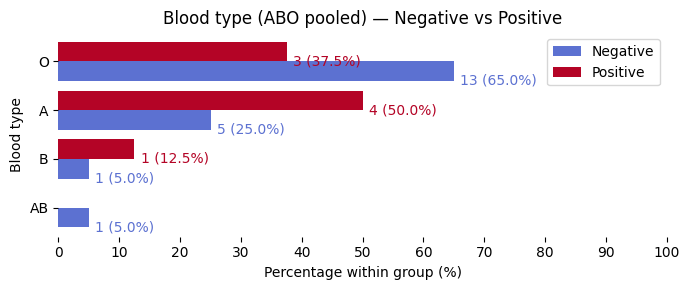

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,AB,1,20,5.0%,0,8,0.0%,0.050,,,,,,,1.000
1,B,1,20,5.0%,1,8,12.5%,-0.075,0.368,0.020,6.723,0.497,-0.272,small,0.663
2,A,5,20,25.0%,4,8,50.0%,-0.250,0.333,0.060,1.854,0.371,-0.524,medium,0.663
3,O,13,20,65.0%,3,8,37.5%,0.275,3.095,0.565,16.958,0.231,0.557,medium,0.663


In [13]:
# Blood groups

# Map  groups
def map_to_abo(value: str):
    v = str(value).strip()
    if v == "" or v.casefold() == "unsure":
        return None
    v = v.upper().replace(" ", "")
    if v in {"A+", "A-"} or v == "A":
        return "A"
    if v in {"B+", "B-"} or v == "B":
        return "B"
    if v in {"AB+", "AB-"} or v == "AB":
        return "AB"
    if v in {"O+", "O-"} or v == "O":
        return "O"
    return None

# Plot
out = plot_secretor_bars(
    Survey_endo_only_sec,
    question_col="What is your blood type?",
    category_func=map_to_abo,                             
    category_order=["AB","B","A","O"],       
    remove_values=("unsure","",np.nan),
    rescale_to_100=True,
    fig_title="Blood type (ABO pooled) — Negative vs Positive",
    y_label="Blood type"
)

# Results table
out["results_formatted"]

## Correlation of blood group- positive vs negative with secretor status

In [15]:
# Correlation - if blood groups factor (negative and positive) correlate with secretor status

df = Survey_endo_only_sec.copy()

# -Recode "blood type" into Positive / Negative from Rh symbol 
df["Blood_Rh"] = df["What is your blood type?"].str.contains(r"\+", regex=True).map({True: "Positive"})
df.loc[df["What is your blood type?"].str.contains(r"-", regex=True), "Blood_Rh"] = "Negative"

# Extract Secretor status
df["Secretor_status"] = df["What is your secretor status"].map({
    "Positive": "Positive",
    "Negative": "Negative"
})

# Drop rows where either variable is missing
df2 = df.dropna(subset=["Blood_Rh", "Secretor_status"])

# Contingency table 
ct = pd.crosstab(df2["Secretor_status"], df2["Blood_Rh"])
print("Contingency table:")
display(ct)

# Determine whether Fisher or Chi-square should be used (small N)
use_fisher = (ct.values < 5).any()

# Statistical test
if use_fisher:
    # Fisher's exact test needs a 2x2 matrix
    oddsratio, p_value = fisher_exact(ct)
    test_name = "Fisher's Exact Test"
else:
    chi2, p_value, dof, expected = chi2_contingency(ct)
    test_name = "Chi-square Test"

# Cramér’s V - effect size
n = ct.sum().sum()
chi2_for_v = chi2_contingency(ct)[0] if not use_fisher else oddsratio  # fallback but Fisher doesn't provide chi2
cramers_v = math.sqrt(chi2_for_v / (n * (min(ct.shape) - 1)))

print(f"\nTest used: {test_name}")
print(f"P-value: {p_value:.4f}")
print(f"Cramér's V: {cramers_v:.4f}")

Contingency table:


Blood_Rh,Negative,Positive
Secretor_status,,
Negative,14,6
Positive,0,8



Test used: Fisher's Exact Test
P-value: 0.0019
Cramér's V: inf


In [16]:
# Correct effect size- as it is infinite due to zero

In [17]:
def cramers_v_bias_corrected_with_label(confusion_matrix):
    """
    Computes bias-corrected Cramér's V according to Bergsma (2013).
    Works with small samples and avoids infinite values.
    """
    chi2, _, _, expected = chi2_contingency(confusion_matrix, correction=False)

    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    # Correction term
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    r_corr = r - ((r - 1)**2) / (n - 1)
    k_corr = k - ((k - 1)**2) / (n - 1)

    # Cramér's V (corrected)
    v_corr = np.sqrt(phi2_corr / min(r_corr - 1, k_corr - 1))


    # Effect size interpretation (2×2 table thresholds) 
    if v_corr < 0.10:
        label = "small effect size"
    elif v_corr < 0.30:
        label = "medium effect size"
    else:
        label = "large effect size"
    
    return v_corr, label

In [18]:
V_corrected, V_label = cramers_v_bias_corrected_with_label(ct)
print(f"Bias‑corrected Cramér’s V: {V_corrected:.4f} ({V_label})")

Bias‑corrected Cramér’s V: 0.6139 (large effect size)


##  Other gyneacological conditions 

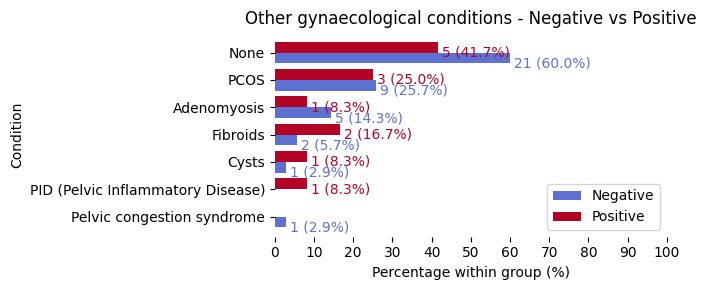

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Pelvic congestion syndrome,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,PID (Pelvic Inflammatory Disease),0,35,0.0%,1,12,8.3%,-0.083,,,,,,,1.000
2,Cysts,1,35,2.9%,1,12,8.3%,-0.055,0.324,0.019,5.615,0.450,-0.246,small,1.000
3,Fibroids,2,35,5.7%,2,12,16.7%,-0.110,0.303,0.038,2.435,0.266,-0.358,small,1.000
4,Adenomyosis,5,35,14.3%,1,12,8.3%,0.060,1.833,0.192,17.489,1.000,0.190,negligible,1.000


In [20]:
# Other gyneacological conditions

QUESTION_COL = "Please list any other gynaecological conditions you have been diagnosed with "
SECRETOR_COL = "What is your secretor status"

# Custom category mapper with priority logic (PCOS > Cysts) 
def map_gyn_other_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # PCOS (separate because it contains "cyst" textually) 
    has_pcos = bool(re.search(r'\bpcos\b', sn))

    if has_pcos:
        categories_found.append("PCOS")

    # Cysts (only if PCOS not present) 
    has_cyst = bool(re.search(r'\bcyst(s)?\b', sn))
    if has_cyst and not has_pcos:
        categories_found.append("Cysts")

    # Other categories (can all co-occur) 
    patterns = {
        "PID (Pelvic Inflammatory Disease)": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Cervical cancer": [r'cervical cancer'],
        "Endometrial cancer": [r'endometrial cancer'],
        "Adenomyosis": [r'\badenomyosis\b'],
        "Fibroids": [r'\bfibroid(s)?\b'],
        "Endosalpingiosis": [r'endosalpingiosis'],
        "Pelvic congestion syndrome": [r'pelvic congestion syndrome'],
        "Infertility": [r'\binfertilit(y|ies)\b', r'\bsubfertilit(y|ies)\b']
    }

    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot   
# Percent of respondents (here the categories do not sum up to 100%, I want to know how many respondents have the given condition including none
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_gyn_other_multilabel,
    multi_label=True,             # count all mentioned categories
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=False,         # % of respondents
    sort_by="combined",
    legend_loc="lower right",
    fig_title="Other gynaecological conditions - Negative vs Positive",
    y_label="Condition"
)


# View results
out["results_formatted"].head()

## What were the first 3 symptoms you noticed?

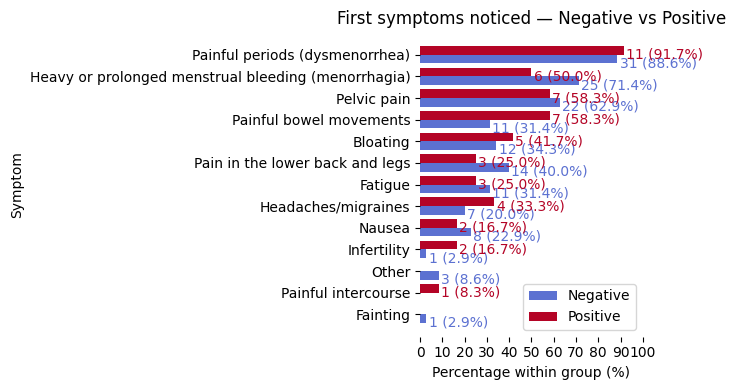

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Fainting,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,Painful intercourse,0,35,0.0%,1,12,8.3%,-0.083,,,,,,,1.000
2,Other,3,35,8.6%,0,12,0.0%,0.086,,,,,,,1.000
3,Infertility,1,35,2.9%,2,12,16.7%,-0.138,0.147,0.012,1.795,0.156,-0.501,medium,1.000
4,Nausea,8,35,22.9%,2,12,16.7%,0.062,1.481,0.268,8.199,1.000,0.156,negligible,1.000
5,Headaches/migraines,7,35,20.0%,4,12,33.3%,-0.133,0.500,0.116,2.149,0.435,-0.304,small,1.000
6,Fatigue,11,35,31.4%,3,12,25.0%,0.064,1.375,0.310,6.094,1.000,0.143,negligible,1.000
7,Pain in the lower back and legs,14,35,40.0%,3,12,25.0%,0.150,2.000,0.459,8.710,0.492,0.322,small,1.000
8,Bloating,12,35,34.3%,5,12,41.7%,-0.074,0.730,0.191,2.799,0.733,-0.152,negligible,1.000
9,Painful bowel movements,11,35,31.4%,7,12,58.3%,-0.269,0.327,0.085,1.265,0.168,-0.548,medium,1.000


In [22]:
# What were the symptoms you noticed?

QUESTION_COL = "What were the first 3 symptoms you noticed?"
SECRETOR_COL = "What is your secretor status"

# Category mapper
def map_symptoms_multilabel(raw: str):
    """
    Multilabel mapper for the free-text symptom question.

    Categories detected (co-occur allowed):
    - Pelvic pain
    - Painful periods (dysmenorrhea)
    - Heavy or prolonged menstrual bleeding (menorrhagia)
    - Painful bowel movements
    - Fatigue
    - Infertility
    - Bloating
    - Nausea  [includes vomiting/retching/throwing up]
    - Pain in the lower back and legs
    - Headaches/migraines
    - Painful intercourse
    - Fainting  [syncope / passed out / blacked out]

    'Other' is added if unknown symptoms are present (e.g., heavy legs, kidney infections,
    bleeding when running/exercising, dizziness/lightheadedness, spotting, constipation, etc.)
    or if list heuristics imply unrecognized items.
    """
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings (strict to avoid false positives) 
    none_patterns = [
        r'^\s*none\s*$', r'^\s*no other\s*$', r'^\s*no\s*$', r'^\s*n/?a\s*$',
        r'^\s*nil\s*$'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Symptom patterns (co-occur allowed)
    patterns = {
        "Pelvic pain": [
            r"\bpelvic pain\b", r"\bpelvic ache\b", r"\bpain in the pelvis\b"
        ],
        "Painful periods (dysmenorrhea)": [
            r"\bpainful periods?\b", r"\bdysmenorrhea\b", r"\bperiod cramps?\b",
            r"\bsevere cramps?\b", r"\bmenstrual cramps?\b"
        ],
        "Heavy or prolonged menstrual bleeding (menorrhagia)": [
            r"\bheavy (or )?prolonged menstrual bleeding\b", r"\bmenorrhagia\b",
            r"\bheavy bleed(ing)?\b", r"\blong(er)? periods?\b",
            # Colloquial heavy-flow terms
            r"\bflooding\b",
            r"\b(pass(ing)? )?clots?\b",
            # Tissue described during periods
            r"\btissue (coming|came) out\b",
            r"\btissue (during|with) (my )?period(s)?\b",
            r"\btissue\b.*\bperiod(s)?\b",
        ],
        "Painful bowel movements": [
            r"\bpainful bowel movements?\b", r"\bpain when (having )?bowel movements?\b"
        ],
        "Fatigue": [
            r"\bfatigue\b", r"\btired(ness)?\b", r"\bexhaust(ion|ed)\b"
        ],
        "Infertility": [
            r"\binfertility\b", r"\bdifficulty (getting|becoming) pregnant\b"
        ],
        "Bloating": [
            r"\bbloating\b", r"\bbloated\b", r"\babdominal distension\b"
        ],
        "Nausea": [
            r"\bnausea\b", r"\bnauseous\b", r"\bqueasy\b",
            # Map vomiting under Nausea
            r"\bvomit(ing)?\b", r"\bretch(ing)?\b", r"\bthrow(ing)? up\b"
        ],
        "Pain in the lower back and legs": [
            r"\bpain in the lower back( and legs)?\b", r"\blower back pain\b",
            r"\bpain in (my|the) legs\b", r"\bleg pain\b"
        ],
        "Headaches/migraines": [
            r"\bheadaches?\b", r"\bmigraines?\b", r"\bmigraine\b"
        ],
        "Painful intercourse": [
            r"\bpainful sex\b", r"\bpainful intercourse\b",
            r"\bpain during intercourse\b", r"\bdyspareunia\b",
            r"\bpain with penetration\b"
        ],
        "Fainting": [
            r"\bfaint(ing)?\b",
            r"\bsyncope\b",
            r"\bpassed out\b", r"\bpass(ing)? out\b",
            r"\bblack(ed)? out\b"
        ],
    }

    # 'Other' symptom hints 
    other_hints = [
        # Pool these to Other 
        r"\bheavy legs?\b",
        r"\bpain (and )?bleeding when running\b",
        r"\bbleeding (when|while) (running|exercis(e|ing))\b",
        r"\breocc?urr?ing kidney infections?\b",
        r"\bkidney infections?\b",

        # General "Other" cues (excluding Fainting & Vomiting which are covered above)
        r"\blight[-\s]?headed(ness)?\b",
        r"\bdizz(y|iness)\b",
        r"\bspotting\b",
        r"\bconstipation\b",
        r"\bdiarrh(oea|hea)\b",
        r"\babdominal pain\b",            # if not captured by pelvic pain wording
        r"\bshoulder pain\b",             # referred pain often mentioned
        r"\bpain (during|with) urination\b", r"\bdysuria\b",
        r"\burinary (frequency|urgency)\b",
    ]

    # Match categories 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion per label

    # If nothing matched at all -> pure Other or None 
    if len(categories_found) == 0:
        if re.search(r"[a-z]", sn):
            return ["Other"]
        else:
            return ["None"]

    # Add 'Other' if non-catalogued symptom cues are present 
    other_flag = any(re.search(p, sn) for p in other_hints)

    # Heuristic: "and other", "etc.", "and more"
    if not other_flag and re.search(r"\band other\b|\betc\.?\b|\band more\b", sn):
        other_flag = True

    # Conservative list heuristic:
    # If the text looks like a list but we matched fewer than likely items, add Other.
    if not other_flag:
        if (("," in sn) or ("/" in sn) or (";" in sn)) and len(categories_found) < 3:
            other_flag = True

    if other_flag and "Other" not in categories_found:
        categories_found.append("Other")

    return categories_found

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_symptoms_multilabel,
    multi_label=True,
    remove_values=(),            # keep everyone in denominator
    rescale_to_100=False,
    sort_by="combined_pos",
    figsize=(7,4), # do not fit into (7,3)
    fig_title="First symptoms noticed — Negative vs Positive",
    legend_loc="lower right",
    y_label="Symptom",
)

# Results table
out["results_formatted"]

## Age of symptoms

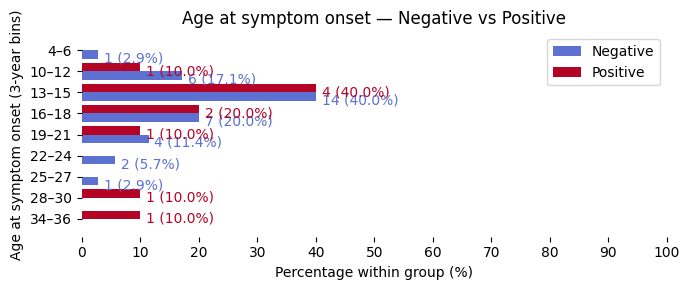

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,34–36,0,35,0.0%,1,10,10.0%,-0.100,,,,,,,1.000
1,28–30,0,35,0.0%,1,10,10.0%,-0.100,,,,,,,1.000
2,25–27,1,35,2.9%,0,10,0.0%,0.029,,,,,,,1.000
3,22–24,2,35,5.7%,0,10,0.0%,0.057,,,,,,,1.000
4,19–21,4,35,11.4%,1,10,10.0%,0.014,1.161,0.115,11.741,1.000,0.046,negligible,1.000
5,16–18,7,35,20.0%,2,10,20.0%,0.000,1.000,0.173,5.795,1.000,0.000,negligible,1.000
6,13–15,14,35,40.0%,4,10,40.0%,0.000,1.000,0.238,4.198,1.000,0.000,negligible,1.000
7,10–12,6,35,17.1%,1,10,10.0%,0.071,1.862,0.197,17.583,1.000,0.210,small,1.000
8,4–6,1,35,2.9%,0,10,0.0%,0.029,,,,,,,1.000


In [24]:
# At what age roughly did you notice your symptoms begin?

QUESTION_COL = "At what age roughly did you notice your symptoms begin?"
SECRETOR_COL = "What is your secretor status"

# Build 3-year bins with en-dash labels (0–3, 4–6, 7–9, ..., 97–99) 
# Keep plausible ages as 1–99.
bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]

# For ordering (highest age at the TOP), we pass bins in DESCENDING label order.
cat_order_desc = [lab for (_, _, lab) in bin_tuples[::-1]]

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    numeric=True,
    number_pattern=r"\d+",          # extract integers from text
    number_extract="first",         # use the first number found in the cell
    numeric_range=(1, 99),          # plausible ages (excludes 0 and >=100)
    numeric_bins=bin_tuples,        # use 3-year bins with custom labels
    rescale_to_100=True,            # denominators = included rows (valid ages)
    remove_values=(),               # don't drop anything else
    sort_by=None,                   # Don't override manual order
    category_order=cat_order_desc,  # highest age bin appears at the top
    fig_title="Age at symptom onset — Negative vs Positive",
    y_label="Age at symptom onset (3-year bins)",
)

# Results table
out["results_formatted"]

In [25]:
# At what age roughly did you notice your symptoms begin?

QUESTION_COL = "At what age roughly did you notice your symptoms begin?"
SECRETOR_COL = "What is your secretor status"

# Extract arrays for Negative / Positive
neg_age, pos_age = extract_age_arrays(
    Survey_endo_only_sec,
    column=QUESTION_COL,
    SECRETOR_COL=SECRETOR_COL,
    groups=("Negative", "Positive"),   
    number_pattern=r"\d+",             # match integers
    number_extract="first",            # or "max" to take the largest in a string
    plausible_range=(1, 99)
)

# Results stats
print("\n=== Summary: Age of sympotom onset ===")
summary = report_overall_timing_stats(neg_age, pos_age, n_boot=5000, seed=42, verbose=True)


=== Summary: Age of sympotom onset ===
Cohen's d (Negative - Positive): -0.524
Welch's t-test: t=-1.277, df=10.5, p=0.2292
Mean difference (Neg - Pos): -3.14 years
95% CI for mean difference: [-8.14, 1.11] years
Effect size magnitude: medium
Significant at α=0.05? NO


## Pain

In [27]:
# How many respondents mentioned pain?

STATUS_COL = 'What is your secretor status'
QUESTION_COL = 'What were the first 3 symptoms you noticed?'

# Build group-specific series of (non-null) responses 
neg_sym = Survey_endo_only_sec[Survey_endo_only_sec[STATUS_COL] == 'Negative'][QUESTION_COL].dropna()
pos_sym = Survey_endo_only_sec[Survey_endo_only_sec[STATUS_COL] == 'Positive'][QUESTION_COL].dropna()

# Mask: 'pain' mentioned (captures 'pain', 'painful', 'pains', etc.) 
pain_pattern = r'\bpain\w*'   # word-boundary + any suffix
neg_pain_mask = neg_sym.str.contains(pain_pattern, case=False, na=False)
pos_pain_mask = pos_sym.str_contains(pain_pattern, case=False, na=False) if hasattr(pos_sym, 'str_contains') else pos_sym.str.contains(pain_pattern, case=False, na=False)

# Counts & totals (per respondents who answered this question) 
x_neg = int(neg_pain_mask.sum())
x_pos = int(pos_pain_mask.sum())
n_neg = len(neg_sym)
n_pos = len(pos_sym)
p_neg = x_neg / n_neg if n_neg > 0 else np.nan
p_pos = x_pos / n_pos if n_pos > 0 else np.nan

print(f"Negative group: {x_neg}/{n_neg} mentioned pain ({p_neg*100:.1f}%)")
print(f"Positive group: {x_pos}/{n_pos} mentioned pain ({p_pos*100:.1f}%)")

Negative group: 35/35 mentioned pain (100.0%)
Positive group: 12/12 mentioned pain (100.0%)


## Pain in childhood

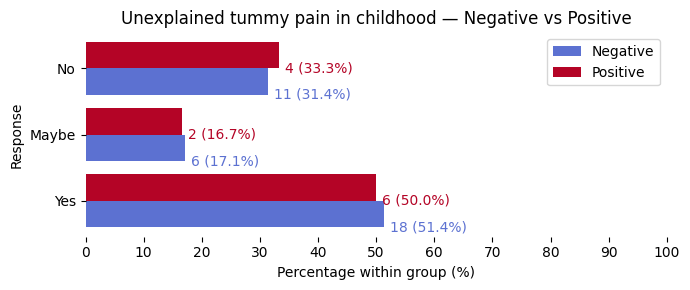

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,18,35,51.4%,6,12,50.0%,0.014,1.059,0.285,3.930,1.000,0.029,negligible,1.000
1,Maybe,6,35,17.1%,2,12,16.7%,0.005,1.034,0.179,5.979,1.000,0.013,negligible,1.000
2,No,11,35,31.4%,4,12,33.3%,-0.019,0.917,0.227,3.704,1.000,-0.041,negligible,1.000


In [29]:
# Did you have any unexplained pain in your tummy as a child?

QUESTION_COL = "Did you have any unexplained pain in your tummy as a child?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "Maybe", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "Maybe", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Unexplained tummy pain in childhood — Negative vs Positive",
    y_label="Response",
    legend_loc="upper right",
)

# Results table
out["results_formatted"].head()

## Timing of tummy pain

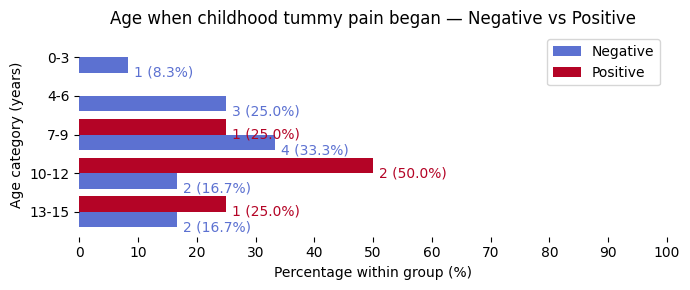

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,13-15,2,12,16.7%,1,4,25.0%,-0.083,0.600,0.039,9.156,1.000,-0.206,small,1.000
1,10-12,2,12,16.7%,2,4,50.0%,-0.333,0.200,0.017,2.386,0.245,-0.730,medium,1.000
2,7-9,4,12,33.3%,1,4,25.0%,0.083,1.500,0.116,19.437,1.000,0.184,negligible,1.000
3,4-6,3,12,25.0%,0,4,0.0%,0.250,,,,,,,1.000
4,0-3,1,12,8.3%,0,4,0.0%,0.083,,,,,,,1.000


In [31]:
# If yes, at what age did this pain begin?

QUESTION_COL = "If yes, at what age did this pain begin?"
SECRETOR_COL = "What is your secretor status"

# Define the desired order from youngest to oldest
age_order = ["0-3","4-6","7-9","10-12","13-15","16-18","19-21","22-24","25-27","28-30"]

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    rescale_to_100=True,         # % among those who answered
    sort_by=None,                # keep manual order
    category_order=list(reversed(age_order)),   # youngest at the top
    fig_title="Age when childhood tummy pain began — Negative vs Positive",
    y_label="Age category (years)",

)

# Results table
out["results_formatted"]

In [32]:
# If yes, at what age did this pain begin?

QUESTION_COL = "If yes, at what age did this pain begin?"
SECRETOR_COL = "What is your secretor status"

# Extract arrays for Negative / Positive
neg_age, pos_age = extract_age_arrays(
    Survey_endo_only_sec,
    column=QUESTION_COL,
    SECRETOR_COL=SECRETOR_COL,
    groups=("Negative", "Positive"),   
    number_pattern=r"\d+",             # match integers
    number_extract="first",            # or "max" to take the largest in a string
    plausible_range=(1, 99)
)

# Run stats 
print("\n=== Summary: Childhood tummy pain ===")
summary = report_overall_timing_stats(neg_age, pos_age, n_boot=5000, seed=42, verbose=True)


=== Summary: Childhood tummy pain ===
Cohen's d (Negative - Positive): -0.749
Welch's t-test: t=-1.381, df=7.3, p=0.2079
Mean difference (Neg - Pos): -2.18 years
95% CI for mean difference: [-4.98, 0.61] years
Effect size magnitude: medium
Significant at α=0.05? NO


## Tummy pain timing regarding periods

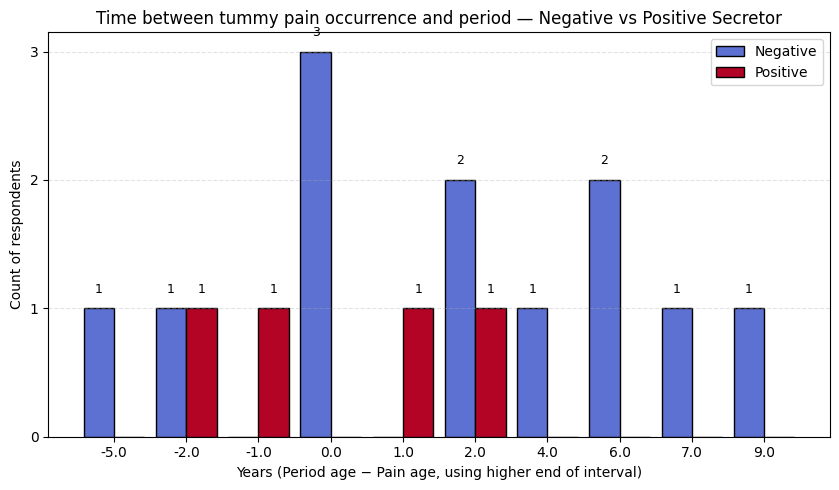


=== Summary: Time between pain and period (years) ===
Negative group: n=12, mean=2.42, SD=4.10
Positive group: n=4, mean=0.00, SD=1.83

Mean difference (Neg - Pos): 2.42 years
95% CI for mean difference: [-0.83, 5.67] years
Welch's t-test: t=1.617, df=12.2, p=0.1315
Cohen's d: 0.648 (medium)
Significant at α=0.05? NO


In [34]:
# Tummy pain timing

# Helper: parse the "interval" and take the higher number 
def extract_highest_age(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        # already numeric
        return float(value)
    s = str(value).replace("–", "-").replace("—", "-")
    nums = re.findall(r"\d+", s)
    if not nums:
        return np.nan
    return max(float(n) for n in nums)

# Column names 
col_period = 'At what age did your period begin?'
col_pain   = 'If yes, at what age did this pain begin?'
status_col = 'What is your secretor status'
diff_col   = 'Min time interval between tummy pain occurrence and period'

Survey_endo_only_sec = Survey_endo_only_sec.copy()

# Derive numeric ages & difference 
Survey_endo_only_sec['_pain_age_high'] = Survey_endo_only_sec[col_pain].apply(extract_highest_age)
Survey_endo_only_sec['_period_age']    = pd.to_numeric(Survey_endo_only_sec[col_period], errors='coerce')
Survey_endo_only_sec[diff_col]         = Survey_endo_only_sec['_period_age'] - Survey_endo_only_sec['_pain_age_high']

# Keep only rows with the diff and status present (Negative/Positive)
valid = Survey_endo_only_sec.loc[Survey_endo_only_sec[diff_col].notna() & Survey_endo_only_sec[status_col].isin(['Negative', 'Positive'])].copy()

# Split groups 
neg = valid.loc[valid[status_col] == 'Negative', diff_col]
pos = valid.loc[valid[status_col] == 'Positive', diff_col]
n_neg = len(neg)
n_pos = len(pos)

# Build aligned counts by bin (years) 
bins = sorted(set(neg.unique()).union(set(pos.unique())))
counts_neg = neg.value_counts().reindex(bins, fill_value=0).astype(int)
counts_pos = pos.value_counts().reindex(bins, fill_value=0).astype(int)

# Side-by-side grouped bar chart (vertical)
x = np.arange(len(bins))
width = 0.42

plt.figure(figsize=(8.5, 5.0))
color_neg = "#5c71d1"  # blue
color_pos = "#b40426"  # red

bars_neg = plt.bar(x - width/2, counts_neg.values, width, label='Negative', color=color_neg, edgecolor='black')
bars_pos = plt.bar(x + width/2, counts_pos.values, width, label='Positive', color=color_pos, edgecolor='black')

# Add counts above bars
for bar in list(bars_neg) + list(bars_pos):
    h = int(bar.get_height())
    if h > 0:
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h}', ha='center', va='bottom', fontsize=9)

# Axis labels & ticks
plt.xticks(x, [str(b) for b in bins], rotation=0)
plt.xlabel("Years (Period age − Pain age, using higher end of interval)")
plt.ylabel("Count of respondents")
plt.title("Time between tummy pain occurrence and period — Negative vs Positive Secretor")

# Force y-axis to show integer-only ticks
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

# Statistics: Welch's t, Cohen's d, 95% CI for mean difference 

def cohens_d(x, y):
    """Cohen's d (pooled SD) between two numeric series."""
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled_sd = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2)) if (nx + ny - 2) > 0 else np.nan
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (x.mean() - y.mean()) / pooled_sd  # Neg - Pos

def welch_t_ci(x, y, alpha=0.05):
    """Welch's t-test and CI for mean difference (Neg - Pos)."""
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan, np.nan, np.nan, (x.mean() - y.mean()), (np.nan, np.nan)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx/nx + vy/ny)
    if se == 0 or np.isnan(se):
        return np.nan, np.nan, np.nan, (mx - my), (np.nan, np.nan)
    t_stat = (mx - my) / se
    # Welch–Satterthwaite df
    num = (vx/nx + vy/ny)**2
    den = (vx**2)/(nx**2*(nx-1)) + (vy**2)/(ny**2*(ny-1))
    df_w = num/den if den > 0 else np.nan

    # Try SciPy for exact; else normal approx
    try:
        from scipy.stats import t as tdist
        p_val = 2 * tdist.sf(abs(t_stat), df_w)
        tcrit = tdist.ppf(1 - alpha/2, df_w)
    except Exception:
        p_val = 2 * (1 - 0.5*(1 + math.erf(abs(t_stat)/math.sqrt(2))))  # normal approx
        tcrit = 1.96 if (not np.isnan(df_w) and df_w > 30) else 2.00

    ci_low  = (mx - my) - tcrit*se
    ci_high = (mx - my) + tcrit*se
    return t_stat, df_w, p_val, (mx - my), (ci_low, ci_high)

d = cohens_d(neg, pos)
t_stat, df_w, p_val, mean_diff, (ci_low, ci_high) = welch_t_ci(neg, pos, alpha=0.05)

# Print summary 
def d_label(d):
    if pd.isna(d): return ''
    a = abs(d)
    if a >= 0.8: return 'large'
    if a >= 0.5: return 'medium'
    if a >= 0.2: return 'small'
    return 'tiny'

print("\n=== Summary: Time between pain and period (years) ===")
print(f"Negative group: n={n_neg}, mean={np.nanmean(neg):.2f}, SD={np.nanstd(neg, ddof=1):.2f}")
print(f"Positive group: n={n_pos}, mean={np.nanmean(pos):.2f}, SD={np.nanstd(pos, ddof=1):.2f}")
print(f"\nMean difference (Neg - Pos): {mean_diff:.2f} years")
print(f"95% CI for mean difference: [{ci_low:.2f}, {ci_high:.2f}] years")
print(f"Welch's t-test: t={t_stat:.3f}, df={df_w:.1f}, p={p_val:.4f}")
print(f"Cohen's d: {d:.3f} ({d_label(d)})")
print("Significant at α=0.05?", "YES" if (p_val < 0.05) else "NO")

## Periods

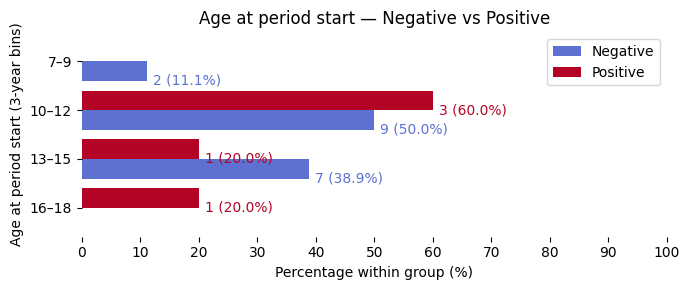

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,16–18,0,18,0.0%,1,5,20.0%,-0.200,,,,,,,1.000
1,13–15,7,18,38.9%,1,5,20.0%,0.189,2.545,0.234,27.709,0.621,0.419,small,1.000
2,10–12,9,18,50.0%,3,5,60.0%,-0.100,0.667,0.089,4.994,1.000,-0.201,small,1.000
3,7–9,2,18,11.1%,0,5,0.0%,0.111,,,,,,,1.000


In [36]:
# At what age did your period begin?

QUESTION_COL = "At what age did your period begin?"
SECRETOR_COL = "What is your secretor status"

# Build 3-year bins with en-dash labels (0–3, 4–6, 7–9, ..., 97–99) -
# We’ll keep plausible ages as 1–99.
bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]

# For ordering (highest age at the TOP), we pass bins in DESCENDING label order.
cat_order_desc = [lab for (_, _, lab) in bin_tuples[::-1]]

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    numeric=True,
    number_pattern=r"\d+",          # extract integers from text
    number_extract="first",         # use the first number found in the cell
    numeric_range=(1, 99),          # plausible ages (excludes 0 and >=100)
    numeric_bins=bin_tuples,        # use our 3-year bins with custom labels
    rescale_to_100=True,            # denominators = included rows (valid ages)
    remove_values=(),               # don't drop anything else
    sort_by=None,                   # Don't override manual order
    category_order=cat_order_desc,  # highest age bin appears at the top
    fig_title="Age at period start — Negative vs Positive",
    y_label="Age at period start (3-year bins)",
)

# Results table
out["results_formatted"]

In [37]:
# At what age did your period begin?

QUESTION_COL = "At what age did your period begin?"
SECRETOR_COL = "What is your secretor status"

# Extract arrays for Negative / Positive
neg_age, pos_age = extract_age_arrays(
    Survey_endo_only_sec,
    column=QUESTION_COL,
    SECRETOR_COL=SECRETOR_COL,
    groups=("Negative", "Positive"),   
    number_pattern=r"\d+",             # match integers
    number_extract="first",            # or "max" to take the largest in a string
    plausible_range=(1, 99)
)

# Run stats 
print("\n=== Summary: Age of period onset ===")
summary = report_overall_timing_stats(neg_age, pos_age, n_boot=5000, seed=42, verbose=True)


=== Summary: Age of period onset ===
Cohen's d (Negative - Positive): -0.095
Welch's t-test: t=-0.174, df=5.3, p=0.8681
Mean difference (Neg - Pos): -0.20 years
95% CI for mean difference: [-2.29, 1.60] years
Effect size magnitude: negligible
Significant at α=0.05? NO


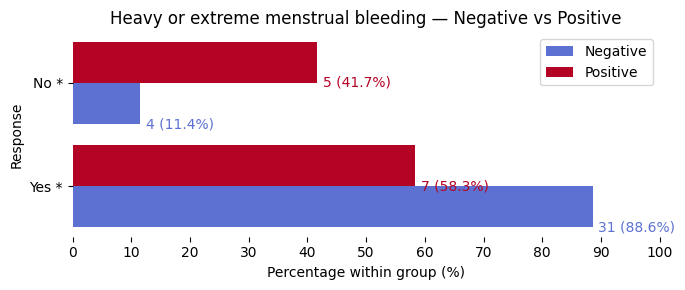

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,31,35,88.6%,7,12,58.3%,0.302,5.536,1.175,26.072,0.035,0.714,medium,0.035
1,No,4,35,11.4%,5,12,41.7%,-0.302,0.181,0.038,0.851,0.035,-0.714,medium,0.035


In [38]:
# Heavy or extreme menstrual bleeding?

QUESTION_COL = "Did/do you suffer from heavy or extreme menstrual bleeding?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Heavy or extreme menstrual bleeding — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

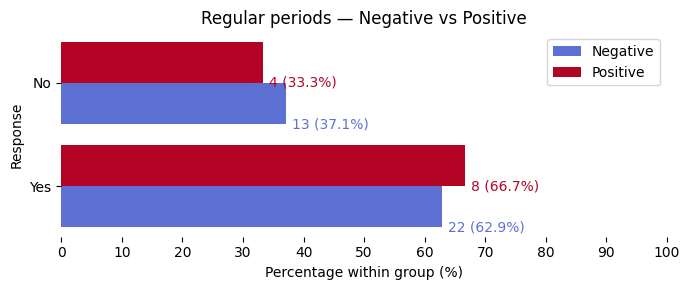

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,22,35,62.9%,8,12,66.7%,-0.038,0.846,0.212,3.371,1.000,-0.080,negligible,1.000
1,No,13,35,37.1%,4,12,33.3%,0.038,1.182,0.297,4.708,1.000,0.080,negligible,1.000


In [39]:
# Regular periods

QUESTION_COL = "Were/are you periods regular?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Regular periods — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

## Skin conditions

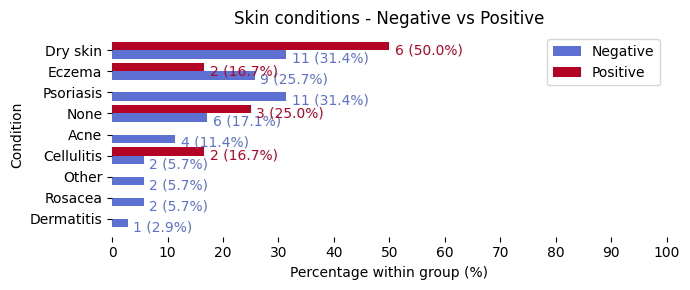

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Dermatitis,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,Rosacea,2,35,5.7%,0,12,0.0%,0.057,,,,,,,1.000
2,Other,2,35,5.7%,0,12,0.0%,0.057,,,,,,,1.000
3,Cellulitis,2,35,5.7%,2,12,16.7%,-0.110,0.303,0.038,2.435,0.266,-0.358,small,1.000
4,Acne,4,35,11.4%,0,12,0.0%,0.114,,,,,,,1.000
5,None,6,35,17.1%,3,12,25.0%,-0.079,0.621,0.129,2.998,0.674,-0.193,negligible,1.000
6,Psoriasis,11,35,31.4%,0,12,0.0%,0.314,,,,,,,1.000
7,Eczema,9,35,25.7%,2,12,16.7%,0.090,1.731,0.317,9.445,0.703,0.223,small,1.000
8,Dry skin,11,35,31.4%,6,12,50.0%,-0.186,0.458,0.120,1.747,0.306,-0.381,small,1.000


In [41]:
# Skin conditions

QUESTION_COL = "Do you suffer from any skin conditions?"
SECRETOR_COL = "What is your secretor status"

# Category mapper 
def map_skin_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "PID (Pelvic Inflammatory Disease)": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Dry skin":    [r"\bdry skin\b"],
        "Eczema":      [r"\beczema\b"],
        "Psoriasis":   [r"\bpsoriasis\b"],
        "Cellulitis":  [r"\bcellulitis\b"],
        "Acne":        [r"\bacne\b"],
        "Rosacea":     [r"\brosacea\b"],
        "Dermatitis":  [r"\bdermatitis\b"],
        "None":        [r"\bnone\b", r"\bn/?a\b", r"\bno\b"]  # avoid "not" to reduce false positives
        }

    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot  
# Percent of respondents (here the categories do not sum up to 100%, I want to know how many respondents have the given condition including none
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_skin_multilabel,
    multi_label=True,             # Count all mentioned categories
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=False,         # % of respondents
    sort_by="combined",
    fig_title="Skin conditions - Negative vs Positive",
    y_label="Condition"
)

# Results table
out["results_formatted"]

## Healing

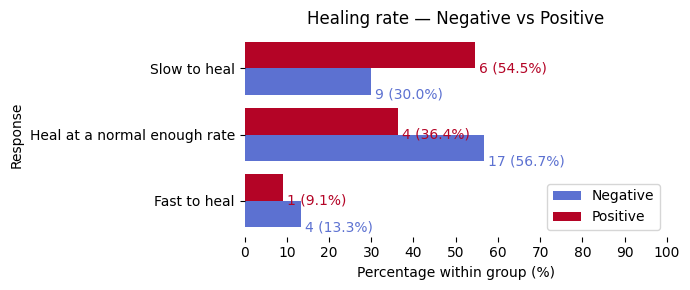

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Fast to heal,4,30,13.3%,1,11,9.1%,0.042,1.538,0.153,15.491,1.000,0.135,negligible,1.000
1,Heal at a normal enough rate,17,30,56.7%,4,11,36.4%,0.203,2.288,0.550,9.515,0.306,0.410,small,0.459
2,Slow to heal,9,30,30.0%,6,11,54.5%,-0.245,0.357,0.086,1.479,0.272,-0.503,medium,0.459


In [43]:
# Did you have any unexplained pain in your tummy as a child?

QUESTION_COL = "When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Fast to heal", "Heal at a normal enough rate", "Slow to heal"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Fast to heal", "Heal at a normal enough rate", "Slow to heal"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Healing rate — Negative vs Positive",
    y_label="Response",
    legend_loc="lower right",
)

# Results table
out["results_formatted"].head()

## Nausea and stomach issues

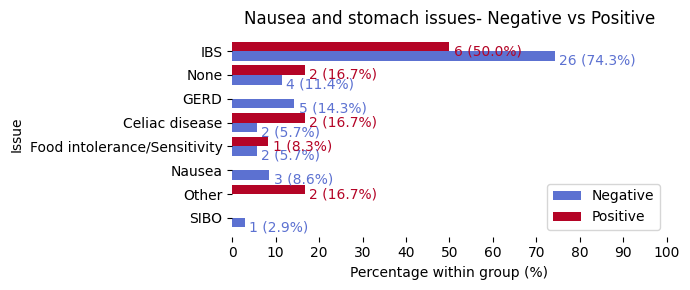

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,SIBO,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,Other,0,35,0.0%,2,12,16.7%,-0.167,,,,,,,1.000
2,Nausea,3,35,8.6%,0,12,0.0%,0.086,,,,,,,1.000
3,Food intolerance/Sensitivity,2,35,5.7%,1,12,8.3%,-0.026,0.667,0.055,8.086,1.000,-0.103,negligible,1.000
4,Celiac disease,2,35,5.7%,2,12,16.7%,-0.110,0.303,0.038,2.435,0.266,-0.358,small,1.000
5,GERD,5,35,14.3%,0,12,0.0%,0.143,,,,,,,1.000
6,None,4,35,11.4%,2,12,16.7%,-0.052,0.645,0.102,4.066,0.637,-0.151,negligible,1.000
7,IBS,26,35,74.3%,6,12,50.0%,0.243,2.889,0.740,11.278,0.158,0.507,medium,1.000


In [45]:
# Nausea and stomach issues

QUESTION_COL = "Do you suffer from nausea or any stomach issues related to or not related to your endometriosis"
SECRETOR_COL = "What is your secretor status"

# Category mapper with priority logic 
def map_nausea_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "IBS": [r"\bibs\b", r"\birritable bowel\b"],
        "SIBO": [r"\bsibo\b"],
        "Celiac disease": [r"\bceliac\b", r"\bcoeliac\b"],
        "GERD": [r"\bgerd\b", r"\bgastro[- ]?esophageal\b", r"\breflux\b"],
        "Nausea": [r"\bnausea\b", r"\bnauseous\b"],
        "Gastritis": [r"\bgastritis\b"],
        "Diarrhea": [r"\bdiarrh?ea\b"],                  # handles American/British spellings
        "Constipation": [r"\bconstipation\b", r"\bconstipated\b"],
        "Bloating": [r"\bbloat(ing|ed)?\b"],
        "Food intolerance/Sensitivity": [r"intoleran", r"sensit"],
        "None": [r"\bnone\b", r"\bn/?a\b", r"\bno\b"]
        }

    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # ---- If nothing matched yet → assign "Other" ----
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot
# Percent of respondents (here the categories do not sum up to 100%, I want to know how many respondents have the given condition including none
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_nausea_multilabel,
    multi_label=True,             # <-- NEW: count all mentioned categories
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=False,         # % of respondents
    sort_by="combined",
    legend_loc="lower right",
    fig_title="Nausea and stomach issues- Negative vs Positive",
    y_label="Issue"
)


# Results table
out["results_formatted"]

## Swallen belly

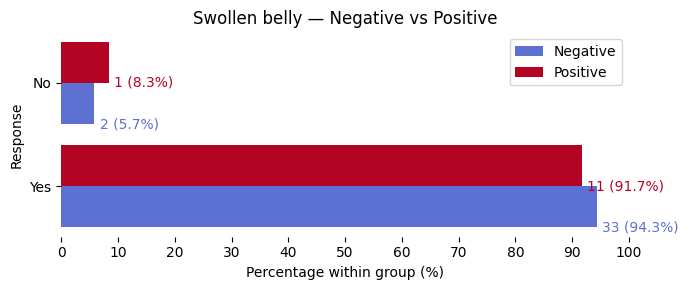

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,33,35,94.3%,11,12,91.7%,0.026,1.500,0.124,18.193,1.000,0.103,negligible,1.000
1,No,2,35,5.7%,1,12,8.3%,-0.026,0.667,0.055,8.086,1.000,-0.103,negligible,1.000


In [47]:
# Swallen belly

QUESTION_COL = "Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "Maybe", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "Maybe", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Swollen belly — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

## Painful bowel movements

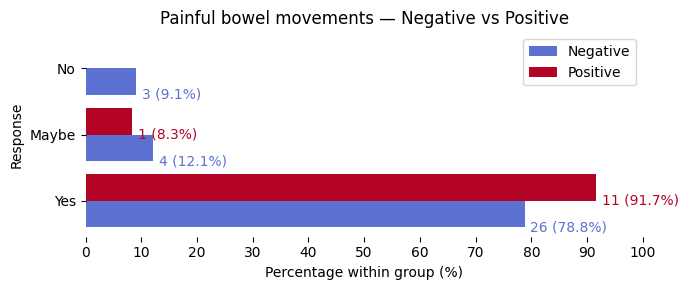

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,26,33,78.8%,11,12,91.7%,-0.129,0.338,0.037,3.080,0.419,-0.372,small,1.000
1,Maybe,4,33,12.1%,1,12,8.3%,0.038,1.517,0.152,15.112,1.000,0.126,negligible,1.000
2,No,3,33,9.1%,0,12,0.0%,0.091,,,,,,,1.000


In [49]:
# Painful bowel movements?

QUESTION_COL = "Do/have you suffered from painful bowel movements?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "Maybe", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "Maybe", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Painful bowel movements — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

## Food and drinks which aggravate symptoms

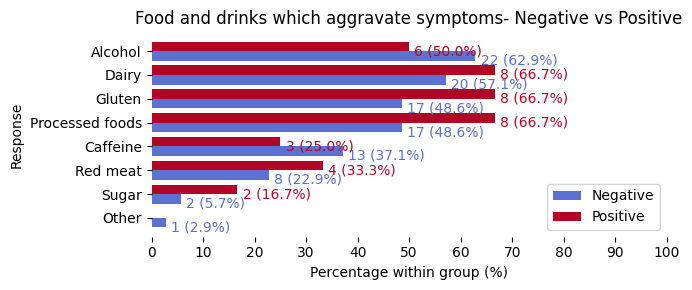

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Other,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,Sugar,2,35,5.7%,2,12,16.7%,-0.110,0.303,0.038,2.435,0.266,-0.358,small,0.675
2,Red meat,8,35,22.9%,4,12,33.3%,-0.105,0.593,0.141,2.492,0.471,-0.234,small,0.675
3,Caffeine,13,35,37.1%,3,12,25.0%,0.121,1.773,0.405,7.753,0.505,0.264,small,0.675
4,Processed foods,17,35,48.6%,8,12,66.7%,-0.181,0.472,0.120,1.860,0.331,-0.368,small,0.675
5,Gluten,17,35,48.6%,8,12,66.7%,-0.181,0.472,0.120,1.860,0.331,-0.368,small,0.675
6,Dairy,20,35,57.1%,8,12,66.7%,-0.095,0.667,0.169,2.635,0.737,-0.196,negligible,0.842
7,Alcohol,22,35,62.9%,6,12,50.0%,0.129,1.692,0.451,6.355,0.506,0.260,small,0.675


In [51]:
# Food and drinks which aggravate symptoms

QUESTION_COL = "Are there any types of foods or drinks that aggravate any of your symptoms?"
SECRETOR_COL = "What is your secretor status"

# Custom category mapper 
def map_food_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "Dairy": [r"\bdairy\b", r"\bmilk\b", r"\bcheese\b", r"\byogh?urt\b"],
        "Red meat": [r"\bred meat\b", r"\bbeef\b", r"\blamb\b"],
        "Gluten": [r"\bgluten\b", r"\bwheat\b"],
        "Processed foods": [r"\bprocessed\b", r"\bfast food\b", r"\bpackaged\b", r"\bjunk\b"],
        "Caffeine": [r"\bcaffeine\b", r"\bcoffee\b", r"\bcaf[eé]\b"],
        "Alcohol": [r"\balcohol\b", r"\bwine\b", r"\bbeer\b", r"\bspirits?\b"],
        "Sugar": [r"\bsugar\b", r"\bsugary\b"],
        "Garlic": [r"\bgarlic\b"],
        "Onions": [r"\bonions?\b"],   
        "None": [
            r"\bnone\b",
            r"\bn/?a\b",
            r"\bnil\b",
            r"\bno\b(?!\s*(change|difference))",  
            r"\bnot sure\b",
            r"\bunsure\b",
            r"\bi('?m| am)? not sure\b",
            r"\bdon'?t know\b",
            r"\bdo not know\b",
            r"\bprefer not\b"
        ]
        }
    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot   
# Percent of respondents (here the categories do not sum up to 100%, I want to know how many respondents have the given condition including none
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_food_multilabel,
    multi_label=True,             # Count all mentioned categories
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=False,         # % of respondents
    sort_by="combined",
    legend_loc="lower right",
    fig_title="Food and drinks which aggravate symptoms- Negative vs Positive",
    y_label="Response"
)


# Results table
out["results_formatted"]

In [52]:
# None category was empty here

## Have you noticed any change in your appetite as your endometriosis has progressed

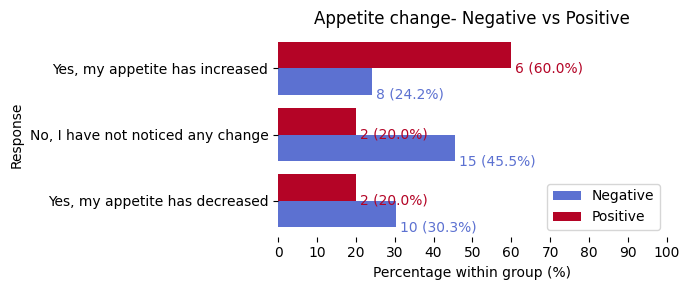

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,"Yes, my appetite has decreased",10,33,30.3%,2,10,20.0%,0.103,1.739,0.312,9.694,0.698,0.239,small,0.698
1,"No, I have not noticed any change",15,33,45.5%,2,10,20.0%,0.255,3.333,0.612,18.142,0.269,0.552,medium,0.403
2,"Yes, my appetite has increased",8,33,24.2%,6,10,60.0%,-0.358,0.213,0.048,0.951,0.055,-0.743,medium,0.165


In [54]:
# Have you noticed any change in your appetite as your endometriosis has progressed-this is better- but need to sort it out properly
QUESTION_COL = "Have you noticed any change in your appetite as your endometriosis has progressed"
SECRETOR_COL = "What is your secretor status"

# Single-label mapper 
def map_appetite_multilabel(raw):
    """
    Maps free text to one of three categories:
      - "Yes, my appetite has decreased"
      - "No, I have not noticed any change"
      - "Yes, my appetite has increased"

    Excludes (returns np.nan) if a response contains signals for BOTH decreased and increased,
    or if 'no change' appears alongside either decreased or increased.
    """

    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return np.nan  # Return NaN so it's excluded cleanly

    s  = str(raw).strip()
    sn = s.casefold()

    decreased_patterns = [
        r"\bdecreas(e|ed|es|ing)?\b",          # decrease / decreased / decreases / decreasing
        r"\breduc(e|ed|es|ing|tion)\b",        # reduce / reduced / reduces / reducing / reduction
        r"\blower\b",                          # lower
        r"\bloss\b",                           # loss
        r"\bloss of appetite\b",               # loss of appetite
        r"\bappetite\s*loss\b",                # appetite loss
        r"\blost appetite\b",                  # lost appetite
        r"\bpoor appetite\b",                  # poor appetite
    ]

    same_patterns = [
        r"\bsame\b",
        r"\bany change\b",
        r"\bsame as before\b",
        r"\bthe same\b",
        r"\bstayed the same\b",
        r"\bremained the same\b",
        r"\bno difference\b",
        r"\bno change\b",
        r"\bunchanged\b",
        r"\bno real change\b",
        r"\bnot changed\b",
        r"\bunchanging\b",
        r"\bsteady\b",
        r"\bstable\b",
    ]

    increased_patterns = [
        # Core "increase" verb family
        r"\bincreas(e|ed|es|ing)\b",

        # Appetite-specific improvements
        r"\bimproved appetite\b",
        r"\bbetter appetite\b",
        r"\bappetite improved\b",
        r"\bimprov(ed|ement)\b.*\bappetite\b",
        r"\bappetite\b.*\bincreas(e|ed|ing)\b",

        # Hunger phrasing
        r"\bhungr(ier|y)\b",            # hungry, hungrier
        r"\bincreased hunger\b",
        r"\bmore hungry\b",
        r"\bravenous\b",
        r"\bgreater hunger\b",

        # “More” intake/portion/quantity phrasing
        r"\beating more\b",
        r"\bmore food\b",
        r"\bmore often\b",
        r"\blarger portions?\b",
        r"\bbigger portions?\b",
        r"\bhigher (intake|consumption)\b",
        r"\bgreater (intake|consumption)\b",

        # General synonyms for “higher”
        r"\bhigher\b",
        r"\bgreater\b",
        r"\belevated\b",
        r"\bheightened\b",

        # Appetite-centric “more” phrasing
        r"\bmore appetite\b",
        r"\bappetite (got|is|feels)?\s*better\b",
    ]

    dec_hit = any(re.search(p, sn) for p in decreased_patterns)
    inc_hit = any(re.search(p, sn) for p in increased_patterns)
    same_hit = any(re.search(p, sn) for p in same_patterns)

    # If both decreased and increased are present, exclude as ambiguous
    if dec_hit and inc_hit:
        return np.nan

    # If "no change/same" appears with either dec or inc, exclude as contradictory
    if same_hit and (dec_hit or inc_hit):
        return np.nan

    # Otherwise map to the single clear category
    if dec_hit:
        return "Yes, my appetite has decreased"

    if same_hit:
        return "No, I have not noticed any change"

    if inc_hit:
        return "Yes, my appetite has increased"

    # If no recognizable keywords, exclude from the pie
    return np.nan

# Categories 
category_order = [
    "Yes, my appetite has decreased",
    "No, I have not noticed any change",
    "Yes, my appetite has increased",
]

# Plot
# Percent of respondents (here the categories do not sum up to 100%, I want to know how many respondents have the given condition including none
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_appetite_multilabel,
    multi_label=True,             # count all mentioned categories
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="combined", 
    category_order=category_order,
    fig_title="Appetite change- Negative vs Positive",
    y_label="Response",
    legend_loc="lower right",
)

# Results table
out["results_formatted"]

## Issues with weight

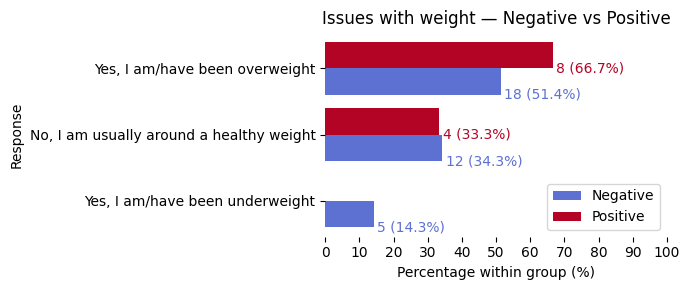

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,"Yes, I am/have been underweight",5,35,14.3%,0,12,0.0%,0.143,,,,,,,1.000
1,"No, I am usually around a healthy weight",12,35,34.3%,4,12,33.3%,0.010,1.043,0.260,4.183,1.000,0.020,negligible,1.000
2,"Yes, I am/have been overweight",18,35,51.4%,8,12,66.7%,-0.152,0.529,0.134,2.086,0.505,-0.311,small,1.000


In [56]:
# Are you or have you ever suffered from issues with your weight?

QUESTION_COL = "Are you or have you ever suffered from issues with your weight?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes, I am/have been underweight", "No, I am usually around a healthy weight","Yes, I am/have been overweight"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes, I am/have been underweight", "No, I am usually around a healthy weight", "Yes, I am/have been overweight"],
    sort_by=None,   # don't auto-reorder
    legend_loc="lower right",
    fig_title="Issues with weight — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

## Fatigue and tiredness

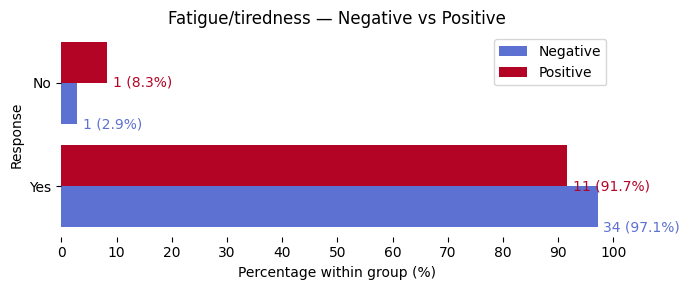

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,34,35,97.1%,11,12,91.7%,0.055,3.091,0.178,53.647,0.450,0.246,small,0.450
1,No,1,35,2.9%,1,12,8.3%,-0.055,0.324,0.019,5.615,0.450,-0.246,small,0.450


In [58]:
# Do you suffer from fatigue or tiredness?

QUESTION_COL = "Do you suffer from fatigue or tiredness?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Fatigue/tiredness — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

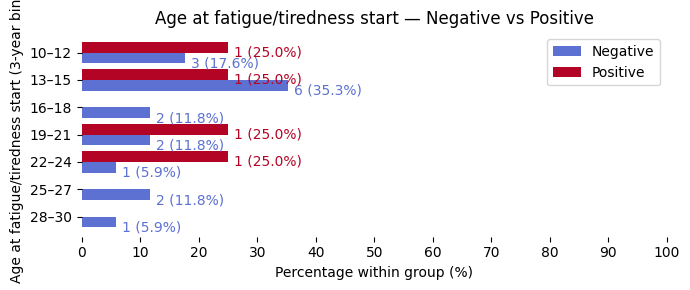

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,28–30,1,17,5.9%,0,4,0.0%,0.059,,,,,,,1.000
1,25–27,2,17,11.8%,0,4,0.0%,0.118,,,,,,,1.000
2,22–24,1,17,5.9%,1,4,25.0%,-0.191,0.188,0.009,3.895,0.352,-0.557,medium,1.000
3,19–21,2,17,11.8%,1,4,25.0%,-0.132,0.400,0.027,5.962,0.489,-0.347,small,1.000
4,16–18,2,17,11.8%,0,4,0.0%,0.118,,,,,,,1.000
5,13–15,6,17,35.3%,1,4,25.0%,0.103,1.636,0.138,19.387,1.000,0.225,small,1.000
6,10–12,3,17,17.6%,1,4,25.0%,-0.074,0.643,0.049,8.517,1.000,-0.180,negligible,1.000


In [59]:
# If yes, at what age did you begin to suffer from this fatigue/tiredness?

QUESTION_COL = "If yes, at what age did you begin to suffer from this fatigue/tiredness?"
SECRETOR_COL = "What is your secretor status"

# Build 3-year bins with en-dash labels (0–3, 4–6, 7–9, ..., 97–99) ---
# We’ll keep plausible ages as 1–99.
bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]

# For ordering (highest age at the TOP), we pass bins in DESCENDING label order.
cat_order_desc = [lab for (_, _, lab) in bin_tuples[::-1]]

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    numeric=True,
    number_pattern=r"\d+",          # extract integers from text
    number_extract="first",         # use the first number found in the cell
    numeric_range=(1, 99),          # plausible ages (excludes 0 and >=100)
    numeric_bins=bin_tuples,        # use our 3-year bins with custom labels
    rescale_to_100=True,            # denominators = included rows (valid ages)
    remove_values=(),               # don't drop anything else
    sort_by=None,                   # IMPORTANT: don't override manual order
    category_order=cat_order_desc,  # highest age bin appears at the top
    fig_title="Age at fatigue/tiredness start — Negative vs Positive",
    y_label="Age at fatigue/tiredness start (3-year bins)",
)

# Results table
out["results_formatted"]

In [60]:
# Timing of fatigue and tiredness

QUESTION_COL = "If yes, at what age did you begin to suffer from this fatigue/tiredness?"
SECRETOR_COL = "What is your secretor status"

# Extract arrays for Negative / Positive
neg_age, pos_age = extract_age_arrays(
    Survey_endo_only_sec,
    column=QUESTION_COL,
    SECRETOR_COL=SECRETOR_COL,
    groups=("Negative", "Positive"),   
    number_pattern=r"\d+",             # match integers
    number_extract="first",            # or "max" to take the largest in a string
    plausible_range=(1, 99)
)

# Run stats 
print("\n=== Summary: Age of fatigue/tiredness onset ===")
summary = report_overall_timing_stats(neg_age, pos_age, n_boot=5000, seed=42, verbose=True)


=== Summary: Age of fatigue/tiredness onset ===
Cohen's d (Negative - Positive): 0.144
Welch's t-test: t=0.276, df=5.3, p=0.7926
Mean difference (Neg - Pos): 0.71 years
95% CI for mean difference: [-3.66, 5.09] years
Effect size magnitude: negligible
Significant at α=0.05? NO


## Mental issues

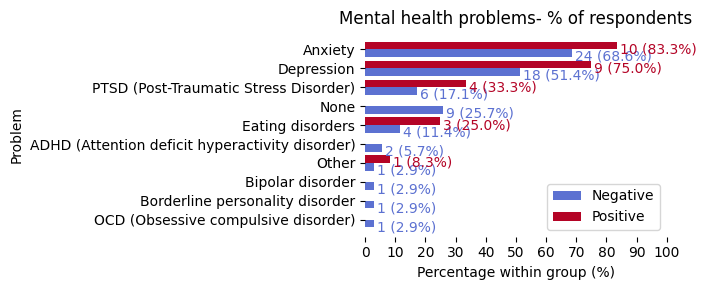

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,OCD (Obsessive compulsive disorder),1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,Borderline personality disorder,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
2,Bipolar disorder,1,35,2.9%,0,12,0.0%,0.029,,,,,,,1.000
3,Other,1,35,2.9%,1,12,8.3%,-0.055,0.324,0.019,5.615,0.450,-0.246,small,0.929
4,ADHD (Attention deficit hyperactivity disorder),2,35,5.7%,0,12,0.0%,0.057,,,,,,,1.000
5,Eating disorders,4,35,11.4%,3,12,25.0%,-0.136,0.387,0.073,2.058,0.350,-0.357,small,0.929
6,None,9,35,25.7%,0,12,0.0%,0.257,,,,,,,1.000
7,PTSD (Post-Traumatic Stress Disorder),6,35,17.1%,4,12,33.3%,-0.162,0.414,0.093,1.832,0.251,-0.377,small,0.929
8,Depression,18,35,51.4%,9,12,75.0%,-0.236,0.353,0.082,1.528,0.191,-0.495,small,0.929
9,Anxiety,24,35,68.6%,10,12,83.3%,-0.148,0.436,0.082,2.336,0.464,-0.349,small,0.929


In [62]:
# Mental issues

QUESTION_COL = "Do/have you ever suffered from mental health problems?"
SECRETOR_COL = "What is your secretor status"

# Custom category mapper 
def map_other_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "Depression": [r"\bdepress(ion|ed)?\b"], # low mood in overall survey not here
        "Anxiety": [r"\banxiet(y|ies)\b", r"\banxious\b"],
        "Bipolar disorder": [r"\bbipolar\b"],  # avoid 'BPD' here (used for Borderline PD)
        "Schizophrenia": [r"\bschizo(phrenia|affective)?\b"],
        "Eating disorders": [r"\beating disorder(s)?\b", r"\banorex(ia|ic)\b", r"\bbulim(ia|ic)\b", r"\beasting disorder(s)?\b"],
        "PTSD (Post-Traumatic Stress Disorder)": [r"\bptsd\b", r"\bpost[- ]traumatic stress\b"],
        "Borderline personality disorder": [r"\bborderline personality\b", r"\bbpd\b"],
        "ADHD (Attention deficit hyperactivity disorder)": [r"\badhd\b", r"\battention[- ]deficit\b"],
        "PMDD (Premenstrual dysphoric disorder)": [r"\bpmdd\b", r"\bpremenstrual dysphoric\b"],
        "OCD (Obsessive compulsive disorder)": [r"\bocd\b", r"\bobsessive[- ]compulsive\b"],
        "None": [r"\bnone\b", r"\bn/?a\b", r"\bno\b"]
        }
    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot   
# Percent of respondents (here the categories do not sum up to 100%, I want to know how many respondents have the given condition including none
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    category_func=map_other_multilabel,
    multi_label=True,             # Count all mentioned categories
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=False,         # % of respondents
    sort_by="combined",
    legend_loc="lower right",
    fig_title="Mental health problems- % of respondents",
    y_label="Problem"
)

# Results table
out["results_formatted"]

## Infection 

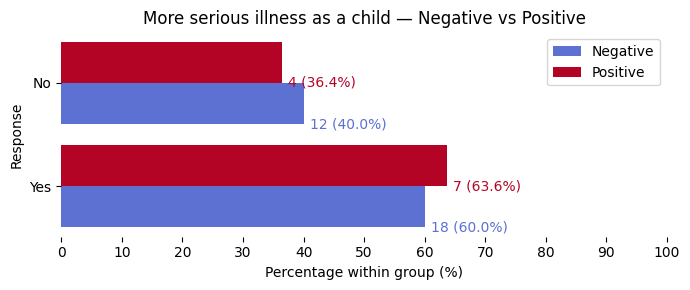

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,18,30,60.0%,7,11,63.6%,-0.036,0.857,0.205,3.579,1.000,-0.075,negligible,1.000
1,No,12,30,40.0%,4,11,36.4%,0.036,1.167,0.279,4.871,1.000,0.075,negligible,1.000


In [64]:
# Illness as a child

QUESTION_COL = "Did you have any illnesses as a child more serious than a common cold or stomach bug?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="More serious illness as a child — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

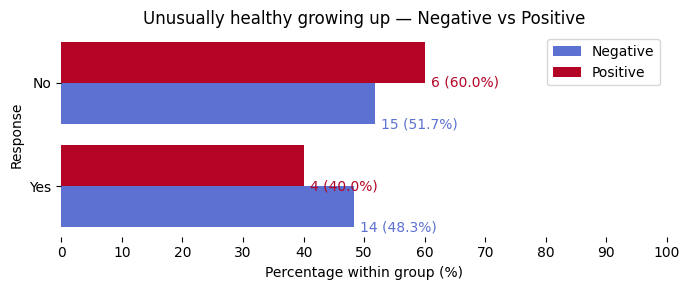

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,14,29,48.3%,4,10,40.0%,0.083,1.400,0.325,6.027,0.726,0.167,negligible,0.726
1,No,15,29,51.7%,6,10,60.0%,-0.083,0.714,0.166,3.075,0.726,-0.167,negligible,0.726


In [65]:
# Were you unusually healthy most of the time with minimum illness growing up?

QUESTION_COL = "Were you unusually healthy most of the time with minimum illness growing up?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Unusually healthy growing up — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

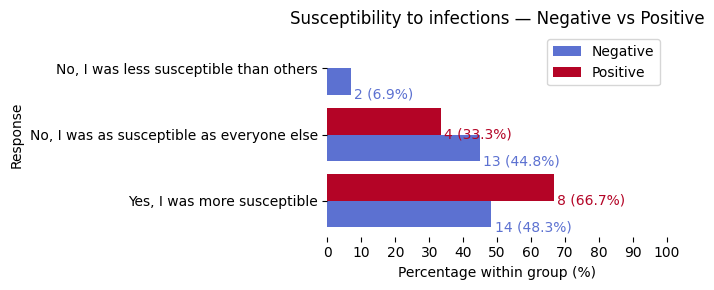

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,"Yes, I was more susceptible",14,29,48.3%,8,12,66.7%,-0.184,0.467,0.115,1.900,0.325,-0.374,small,0.974
1,"No, I was as susceptible as everyone else",13,29,44.8%,4,12,33.3%,0.115,1.625,0.398,6.628,0.729,0.236,small,1.000
2,"No, I was less susceptible than others",2,29,6.9%,0,12,0.0%,0.069,,,,,,,1.000


In [66]:
# Were you more susceptible to bacterial or viral infections than others growing up?

QUESTION_COL = "Were you more susceptible to bacterial or viral infections than others growing up?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes, I was more susceptible", "No, I was as susceptible as everyone else","No, I was less susceptible than others"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes, I was more susceptible", "No, I was as susceptible as everyone else", "No, I was less susceptible than others"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Susceptibility to infections — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

## Bacterial infection

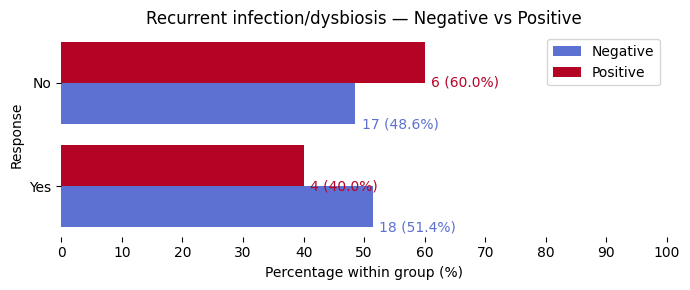

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,18,35,51.4%,4,10,40.0%,0.114,1.588,0.381,6.625,0.722,0.230,small,0.722
1,No,17,35,48.6%,6,10,60.0%,-0.114,0.630,0.151,2.627,0.722,-0.230,small,0.722


In [68]:
# Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?

QUESTION_COL = "Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Recurrent infection/dysbiosis — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

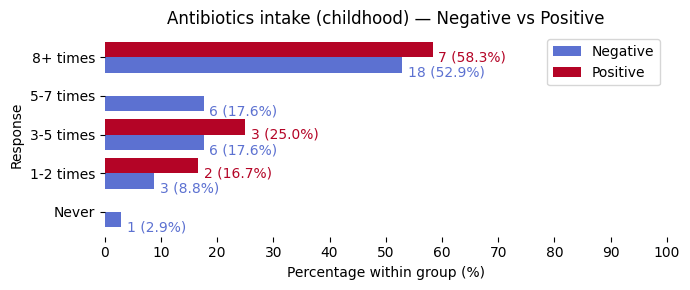

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Never,1,34,2.9%,0,12,0.0%,0.029,,,,,,,1.000
1,1-2 times,3,34,8.8%,2,12,16.7%,-0.078,0.484,0.071,3.320,0.594,-0.238,small,1.000
2,3-5 times,6,34,17.6%,3,12,25.0%,-0.074,0.643,0.133,3.110,0.678,-0.180,negligible,1.000
3,5-7 times,6,34,17.6%,0,12,0.0%,0.176,,,,,,,1.000
4,8+ times,18,34,52.9%,7,12,58.3%,-0.054,0.804,0.212,3.040,1.000,-0.109,negligible,1.000


In [69]:
# Antibiotics intake

QUESTION_COL = "Roughly How many times did you take antibiotics as a child?"
SECRETOR_COL = "What is your secretor status"

out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Never", "1-2 times", "3-5 times", "5-7 times", "8+ times"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Never", "1-2 times", "3-5 times", "5-7 times", "8+ times"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Antibiotics intake (childhood) — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

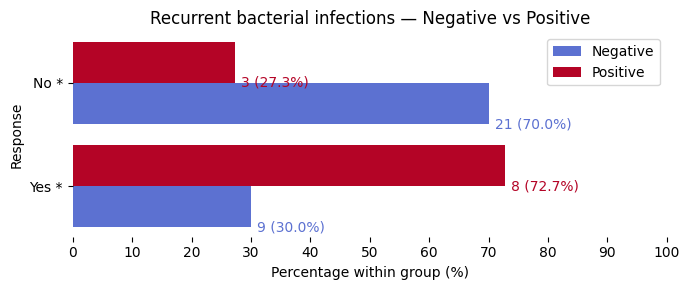

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,9,30,30.0%,8,11,72.7%,-0.427,0.161,0.034,0.749,0.029,-0.883,large,0.029
1,No,21,30,70.0%,3,11,27.3%,0.427,6.222,1.334,29.013,0.029,0.883,large,0.029


In [70]:
# Were you ever diagnosed with any recurrent bacterial infections?

QUESTION_COL = "Were you ever diagnosed with any recurrent bacterial infections?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Recurrent bacterial infections — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

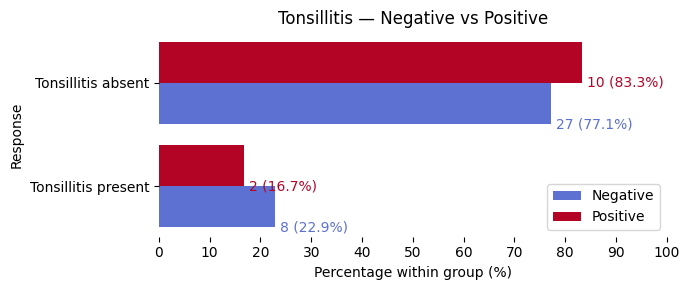

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Tonsillitis present,8,35,22.9%,2,12,16.7%,0.062,1.481,0.268,8.199,1.000,0.156,negligible,1.000
1,Tonsillitis absent,27,35,77.1%,10,12,83.3%,-0.062,0.675,0.122,3.736,1.000,-0.156,negligible,1.000


In [71]:
# Tonsillitis - selection based on overall responses- the answers are in these two colulmns:
# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness

QUESTION_COL1 = "If yes, please list below if you know the name the illness"
QUESTION_COL2 = "If yes, can you name the infection if known?"
SECRETOR_COL = "What is your secretor status"

tonsillitis_regex = re.compile(r"\btonsillitis\b[.,;:]?", re.IGNORECASE)

# Map responses including or excluding tonsillitis
def detect_tonsillitis(row):
    txt1 = str(row[QUESTION_COL1]).casefold() if isinstance(row[QUESTION_COL1], str) else ""
    txt2 = str(row[QUESTION_COL2]).casefold() if isinstance(row[QUESTION_COL2], str) else ""
    combined = txt1 + " " + txt2

    if tonsillitis_regex.search(combined):
        return "Tonsillitis present"
    else:
        return "Tonsillitis absent"

Survey_endo_only_sec = Survey_endo_only_sec.copy()

Survey_endo_only_sec.loc[:, "Tonsillitis_status"] = (
    Survey_endo_only_sec.apply(detect_tonsillitis, axis=1)
)

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col="Tonsillitis_status",
    secretor_col=SECRETOR_COL,
    category_order=["Tonsillitis present", "Tonsillitis absent"],
    include_other=False,
    remove_values=(),
    rescale_to_100=False,
    sort_by="combined",
    legend_loc="lower right",
    fig_title="Tonsillitis — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"]

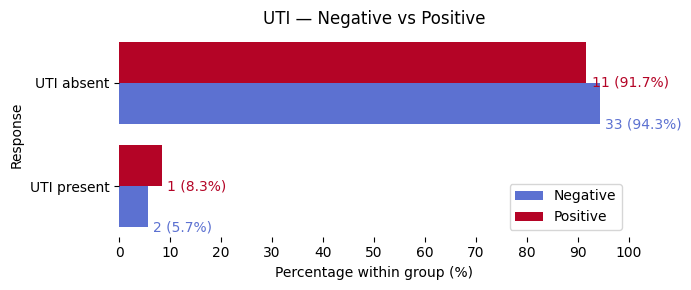

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,UTI present,2,35,5.7%,1,12,8.3%,-0.026,0.667,0.055,8.086,1.000,-0.103,negligible,1.000
1,UTI absent,33,35,94.3%,11,12,91.7%,0.026,1.500,0.124,18.193,1.000,0.103,negligible,1.000


In [72]:
# UTIs

# UTIs- selection based on overall responses- the answers are in these two colulmns:
# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness

QUESTION_COL1 = "If yes, please list below if you know the name the illness"
QUESTION_COL2 = "If yes, can you name the infection if known?"
SECRETOR_COL = "What is your secretor status"

uti_regex = re.compile(
    r"\buti\b|"                                 # UTI standalone
    r"\burinary\s*tract\s*infection[s]?\b|"     # urinary tract infection / infections
    r"\burinary\s*infection[s]?\b",             # urinary infection,     
    re.IGNORECASE
)

# Map responses including or excluding UTIs
def detect_uti(row):
    txt1 = str(row[QUESTION_COL1]).casefold() if isinstance(row[QUESTION_COL1], str) else ""
    txt2 = str(row[QUESTION_COL2]).casefold() if isinstance(row[QUESTION_COL2], str) else ""
    combined = txt1 + " " + txt2

    if uti_regex.search(combined):
        return "UTI present"
    else:
        return "UTI absent"

Survey_endo_only_sec = Survey_endo_only_sec.copy()

Survey_endo_only_sec.loc[:, "UTI_status"] = (
    Survey_endo_only_sec.apply(detect_uti, axis=1)
)

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col="UTI_status",
    secretor_col=SECRETOR_COL,
    category_order=["UTI present", "UTI absent"],
    include_other=False,
    remove_values=(),
    rescale_to_100=False,
    sort_by="combined",
    legend_loc="lower right",
    fig_title="UTI — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"]

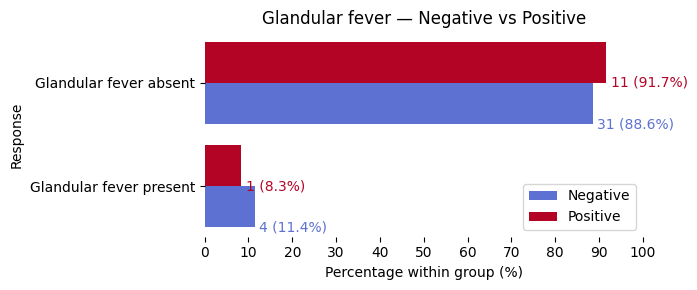

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Glandular fever present,4,35,11.4%,1,12,8.3%,0.031,1.419,0.143,14.111,1.000,0.104,negligible,1.000
1,Glandular fever absent,31,35,88.6%,11,12,91.7%,-0.031,0.705,0.071,7.004,1.000,-0.104,negligible,1.000


In [73]:
# Glandular fever - virus

# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness

QUESTION_COL1 = "If yes, please list below if you know the name the illness"
QUESTION_COL2 = "If yes, can you name the infection if known?"
SECRETOR_COL = "What is your secretor status"

glandular_regex = re.compile(r"\bglandular[- ]?fever\b[.,;:]?", re.IGNORECASE)

# Map responses including or excluding glandular fever
def detect_glandular(row):
    txt1 = str(row[QUESTION_COL1]).casefold() if isinstance(row[QUESTION_COL1], str) else ""
    txt2 = str(row[QUESTION_COL2]).casefold() if isinstance(row[QUESTION_COL2], str) else ""
    combined = txt1 + " " + txt2

    if glandular_regex.search(combined):
        return "Glandular fever present"
    else:
        return "Glandular fever absent"

Survey_endo_only_sec = Survey_endo_only_sec.copy()

Survey_endo_only_sec.loc[:, "Glandular fever_status"] = (
    Survey_endo_only_sec.apply(detect_glandular, axis=1)
)

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col="Glandular fever_status",
    secretor_col=SECRETOR_COL,
    category_order=["Glandular fever present", "Glandular fever absent"],
    include_other=False,
    remove_values=(),
    rescale_to_100=False,
    sort_by="combined",
    legend_loc="lower right",
    fig_title="Glandular fever — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"]

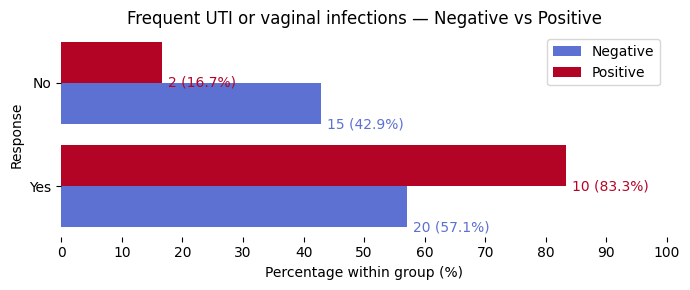

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,20,35,57.1%,10,12,83.3%,-0.262,0.267,0.051,1.401,0.165,-0.586,medium,0.165
1,No,15,35,42.9%,2,12,16.7%,0.262,3.750,0.714,19.707,0.165,0.586,medium,0.165


In [74]:
# Have you had frequent UTI or vaginal infections throughout your life?

QUESTION_COL = "Have you had frequent UTI or vaginal infections throughout your life?"
SECRETOR_COL = "What is your secretor status"

out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Frequent UTI or vaginal infections — Negative vs Positive",
    y_label="Response"
)

# Results table
out["results_formatted"].head()

## COVID-19

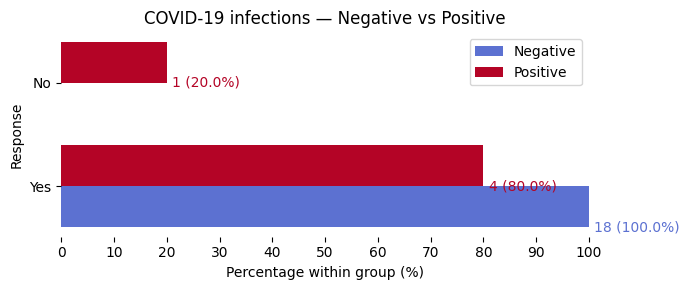

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,18,18,100.0%,4,5,80.0%,0.200,12.333,0.427,355.891,0.217,0.927,large,0.435
1,No,0,18,0.0%,1,5,20.0%,-0.200,,,,,,,1.000


In [76]:
# Did you ever have Covid-19

QUESTION_COL = "Did you ever have Covid-19"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="COVID-19 infections — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

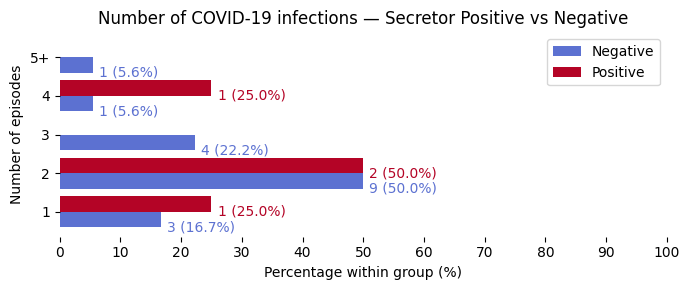

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,1,3,18,16.7%,1,4,25.0%,-0.083,0.600,0.045,7.922,1.000,-0.206,small,1.000
1,2,9,18,50.0%,2,4,50.0%,0.000,1.000,0.115,8.730,1.000,0.000,negligible,1.000
2,3,4,18,22.2%,0,4,0.0%,0.222,,,,,,,1.000
3,4,1,18,5.6%,1,4,25.0%,-0.194,0.176,0.009,3.658,0.338,-0.571,medium,1.000
4,5+,1,18,5.6%,0,4,0.0%,0.056,,,,,,,1.000


In [77]:
# If yes, how many times did you have Covid-19?

# Map written forms to numbers (lowercased)
WORD_TO_NUM = {
    "one": 1, "once": 1,
    "two": 2, "twice": 2,
    "three": 3, "thrice": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
}

# Catch ranges like "2-3", "3/4", "3 to 4"
RANGE_RE = re.compile(r"(\d+)\s*(?:-|\/|to)\s*(\d+)", re.IGNORECASE)

# Catch digits in many forms: "3", "3x", "3 times", "5time", "5x covid"
DIGIT_RE = re.compile(r"\b(\d+)\b|(\d+)\s*[x]|(\d+)\s*times?", re.IGNORECASE)

def extract_count(value):
    """
    Extract an integer count from free text using this precedence:
      1) Numeric ranges (take the max): '2-3', '3/4', '3 to 4'
      2) Any numeric forms: '3', '3x', '4 times', '5time'
      3) Word numbers: 'once', 'twice', 'three', 'five (5)'
    Returns np.nan if nothing meaningful is found.
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    # Try ranges first: take the max as conservative count
    rng = RANGE_RE.search(s)
    if rng:
        try:
            low = int(rng.group(1))
            high = int(rng.group(2))
            return max(low, high)
        except Exception:
            pass

    # Try digit-based patterns
    matches = DIGIT_RE.findall(s)
    if matches:
        nums = []
        for tup in matches:
            for g in tup:
                if g:
                    try:
                        nums.append(int(g))
                    except Exception:
                        pass
        if nums:
            return max(nums)

    # Try word-number mapping (also handles 'five (5)' by the digit path above)
    for word, val in WORD_TO_NUM.items():
        if word in s:
            return val

    # If nothing found
    return np.nan


def bucket_times(n):
    """
    Map integer counts to ordered buckets: '1','2','3','4','5+'.
    Returns None for NaN.
    """
    if pd.isna(n):
        return None
    n = int(n)
    if n <= 1:
        return "1"
    elif n == 2:
        return "2"
    elif n == 3:
        return "3"
    elif n == 4:
        return "4"
    else:
        return "5+"


COVID_TIMES_COL = "If yes, how many times did you have Covid-19?"

Survey_endo_only_sec = Survey_endo_only_sec.copy()

# Extract numeric count
Survey_endo_only_sec.loc[:, "Covid_times_count"] = (
    Survey_endo_only_sec[COVID_TIMES_COL].apply(extract_count)
)

# Bucket into ["1","2","3","4","5+"]
Survey_endo_only_sec.loc[:, "Covid_times_category"] = (
    Survey_endo_only_sec["Covid_times_count"].apply(bucket_times)
)

QUESTION_COL = "Covid_times_category"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["1", "2", "3", "4", "5+"],
    include_other=False,
    remove_values=(np.nan, ""),    # drop missing
    rescale_to_100=True,
    category_order=["1", "2", "3", "4", "5+"],
    sort_by=None,
    fig_title="Number of COVID-19 infections — Secretor Positive vs Negative",
    y_label="Number of episodes"
)

# Results table
out["results_formatted"].head()

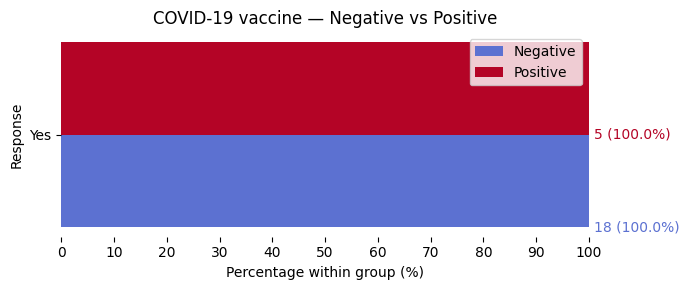

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,18,18,100.0%,5,5,100.0%,0.000,,,,,,,1.000


In [78]:
# Did you receive the covid-19 vaccine?

QUESTION_COL = "Did you receive the covid-19 vaccine?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="COVID-19 vaccine — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

## Allergy

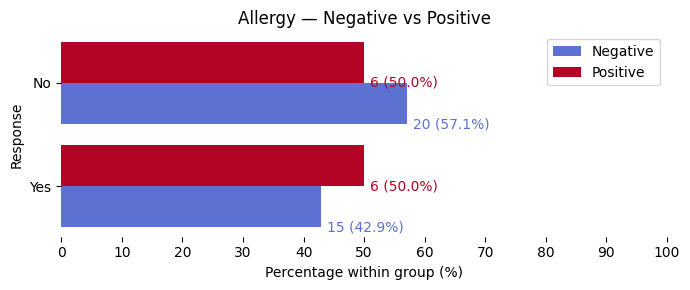

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,15,35,42.9%,6,12,50.0%,-0.071,0.750,0.201,2.793,0.744,-0.143,negligible,0.744
1,No,20,35,57.1%,6,12,50.0%,0.071,1.333,0.358,4.965,0.744,0.143,negligible,0.744


In [80]:
# Are you allergic to anything?

QUESTION_COL = "Are you allergic to anything?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    fig_title="Allergy — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

## Autoimmunity

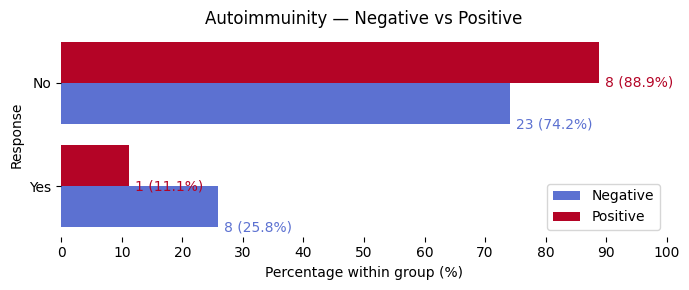

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,8,31,25.8%,1,9,11.1%,0.147,2.783,0.299,25.854,0.654,0.386,small,0.654
1,No,23,31,74.2%,8,9,88.9%,-0.147,0.359,0.039,3.339,0.654,-0.386,small,0.654


In [82]:
# Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?

QUESTION_COL = "Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    legend_loc="lower right",
    fig_title="Autoimmuinity — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()

## Chronic diseases

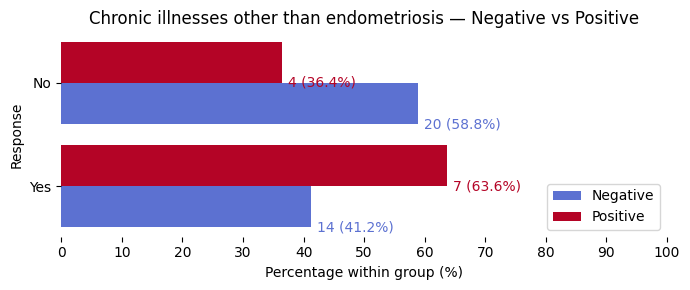

,Category,Negative cases,Negative n,Negative prev,Positive cases,Positive n,Positive prev,Diff (Neg-Pos),OR (Neg/Pos),OR 95% CI low,OR 95% CI high,Fisher two-sided p,Cohen h,Cohen h magnitude,q (BH-FDR)
0,Yes,14,34,41.2%,7,11,63.6%,-0.225,0.400,0.098,1.631,0.299,-0.454,small,0.299
1,No,20,34,58.8%,4,11,36.4%,0.225,2.500,0.613,10.195,0.299,0.454,small,0.299


In [84]:
# Have you been diagnosed with any chronic illnesses other than endometriosis?

QUESTION_COL = "Have you been diagnosed with any chronic illnesses other than endometriosis?"
SECRETOR_COL = "What is your secretor status"

# Plot
out = plot_secretor_bars(
    df=Survey_endo_only_sec,
    question_col=QUESTION_COL,
    secretor_col=SECRETOR_COL,
    allowed_answers=["Yes", "No"],
    include_other=False,              # drop everything else
    remove_values=("", np.nan),       # optionally add "none" if that exists and should be dropped
    rescale_to_100=True,              # denominator = included rows (i.e., Yes/Maybe/No)
    category_order=["Yes", "No"],
    sort_by=None,                     # don't auto-reorder
    legend_loc="lower right",
    fig_title="Chronic illnesses other than endometriosis — Negative vs Positive",
    y_label="Response"
)

# Results table 
out["results_formatted"].head()